# DATATHON 2026 — The Gridbreakers
## EDA Dashboard: Thời trang Thương mại điện tử Việt Nam (2012–2022)
5 Dashboard gom từ 13 charts, style Power BI

- **Dashboard 1** — Tổng quan & Xu hướng Doanh thu
- **Dashboard 2** — Phân tích Sản phẩm & Danh mục
- **Dashboard 3** — Phân tích Khách hàng
- **Dashboard 4** — Khủng hoảng Khuyến mãi & Chuyển đổi
- **Dashboard 5** — Dự báo Chiến lược & Khuyến nghị Hành động


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

DATA_DIR   = Path("./data")
CHARTS_DIR = Path("./charts")
CHARTS_DIR.mkdir(exist_ok=True)

# Power BI inspired palette
BG   = "#F4F6FB"
CARD = "#FFFFFF"
C1, C2, C3, C4, C5 = "#2563EB", "#10B981", "#F59E0B", "#EF4444", "#8B5CF6"
GRAY = "#6B7280"
PAL  = [C1, C2, C3, C4, C5]

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor":   CARD,
    "axes.edgecolor":   "#E5E7EB",
    "axes.labelcolor":  "#374151",
    "axes.titlesize":   11,
    "axes.titleweight": "bold",
    "axes.titlepad":    10,
    "axes.labelsize":   9,
    "xtick.labelsize":  8,
    "ytick.labelsize":  8,
    "grid.color":       "#F3F4F6",
    "grid.linewidth":   0.8,
    "font.family":      "DejaVu Sans",
    "text.color":       "#111827",
    "legend.fontsize":  8,
    "legend.framealpha":0.95,
})

def M(x, _=None):
    if abs(x) >= 1e9: return f"{x/1e9:.1f}B"
    if abs(x) >= 1e6: return f"{x/1e6:.1f}M"
    if abs(x) >= 1e3: return f"{x/1e3:.0f}K"
    return f"{x:.0f}"

def wm(ax):
    ax.text(0.99, 0.01, "DATATHON 2026", transform=ax.transAxes,
            fontsize=6, color="#D1D5DB", ha="right", va="bottom", style="italic")

print("Setup hoàn tất!")

Setup hoàn tất!


In [3]:
files = [
    "sales.csv", "orders.csv", "order_items.csv", "products.csv",
    "customers.csv", "geography.csv", "promotions.csv",
    "returns.csv", "web_traffic.csv", "inventory.csv",
    "payments.csv", "reviews.csv",
]
dfs = {}
for f in files:
    p = DATA_DIR / f
    if p.exists():
        dfs[f] = pd.read_csv(p, low_memory=False)
        print(f"  ✓ {f:<28} {len(dfs[f]):>10,} dòng")
    else:
        print(f"  ✗ THIẾU: {f}")

# Parse ngày tháng
for fname, col in [
    ("sales.csv",      "Date"),
    ("orders.csv",     "order_date"),
    ("customers.csv",  "signup_date"),
    ("web_traffic.csv","date"),
    ("returns.csv",    "return_date"),
]:
    if fname in dfs:
        dfs[fname][col] = pd.to_datetime(dfs[fname][col])

for fname in ["promotions.csv"]:
    if fname in dfs:
        dfs[fname]["start_date"] = pd.to_datetime(dfs[fname]["start_date"])
        dfs[fname]["end_date"]   = pd.to_datetime(dfs[fname]["end_date"])

print("\nNạp dữ liệu hoàn tất!")

  ✓ sales.csv                         3,833 dòng
  ✓ orders.csv                      646,945 dòng
  ✓ order_items.csv                 714,669 dòng
  ✓ products.csv                      2,412 dòng
  ✓ customers.csv                   121,930 dòng
  ✓ geography.csv                    39,948 dòng
  ✓ promotions.csv                       50 dòng
  ✓ returns.csv                      39,939 dòng
  ✓ web_traffic.csv                   3,652 dòng
  ✓ inventory.csv                    60,247 dòng
  ✓ payments.csv                    646,945 dòng
  ✓ reviews.csv                     113,551 dòng

Nạp dữ liệu hoàn tất!


---
## DASHBOARD 1 — Tổng quan & Xu hướng Doanh thu
**Cấp độ: Descriptive + Predictive**


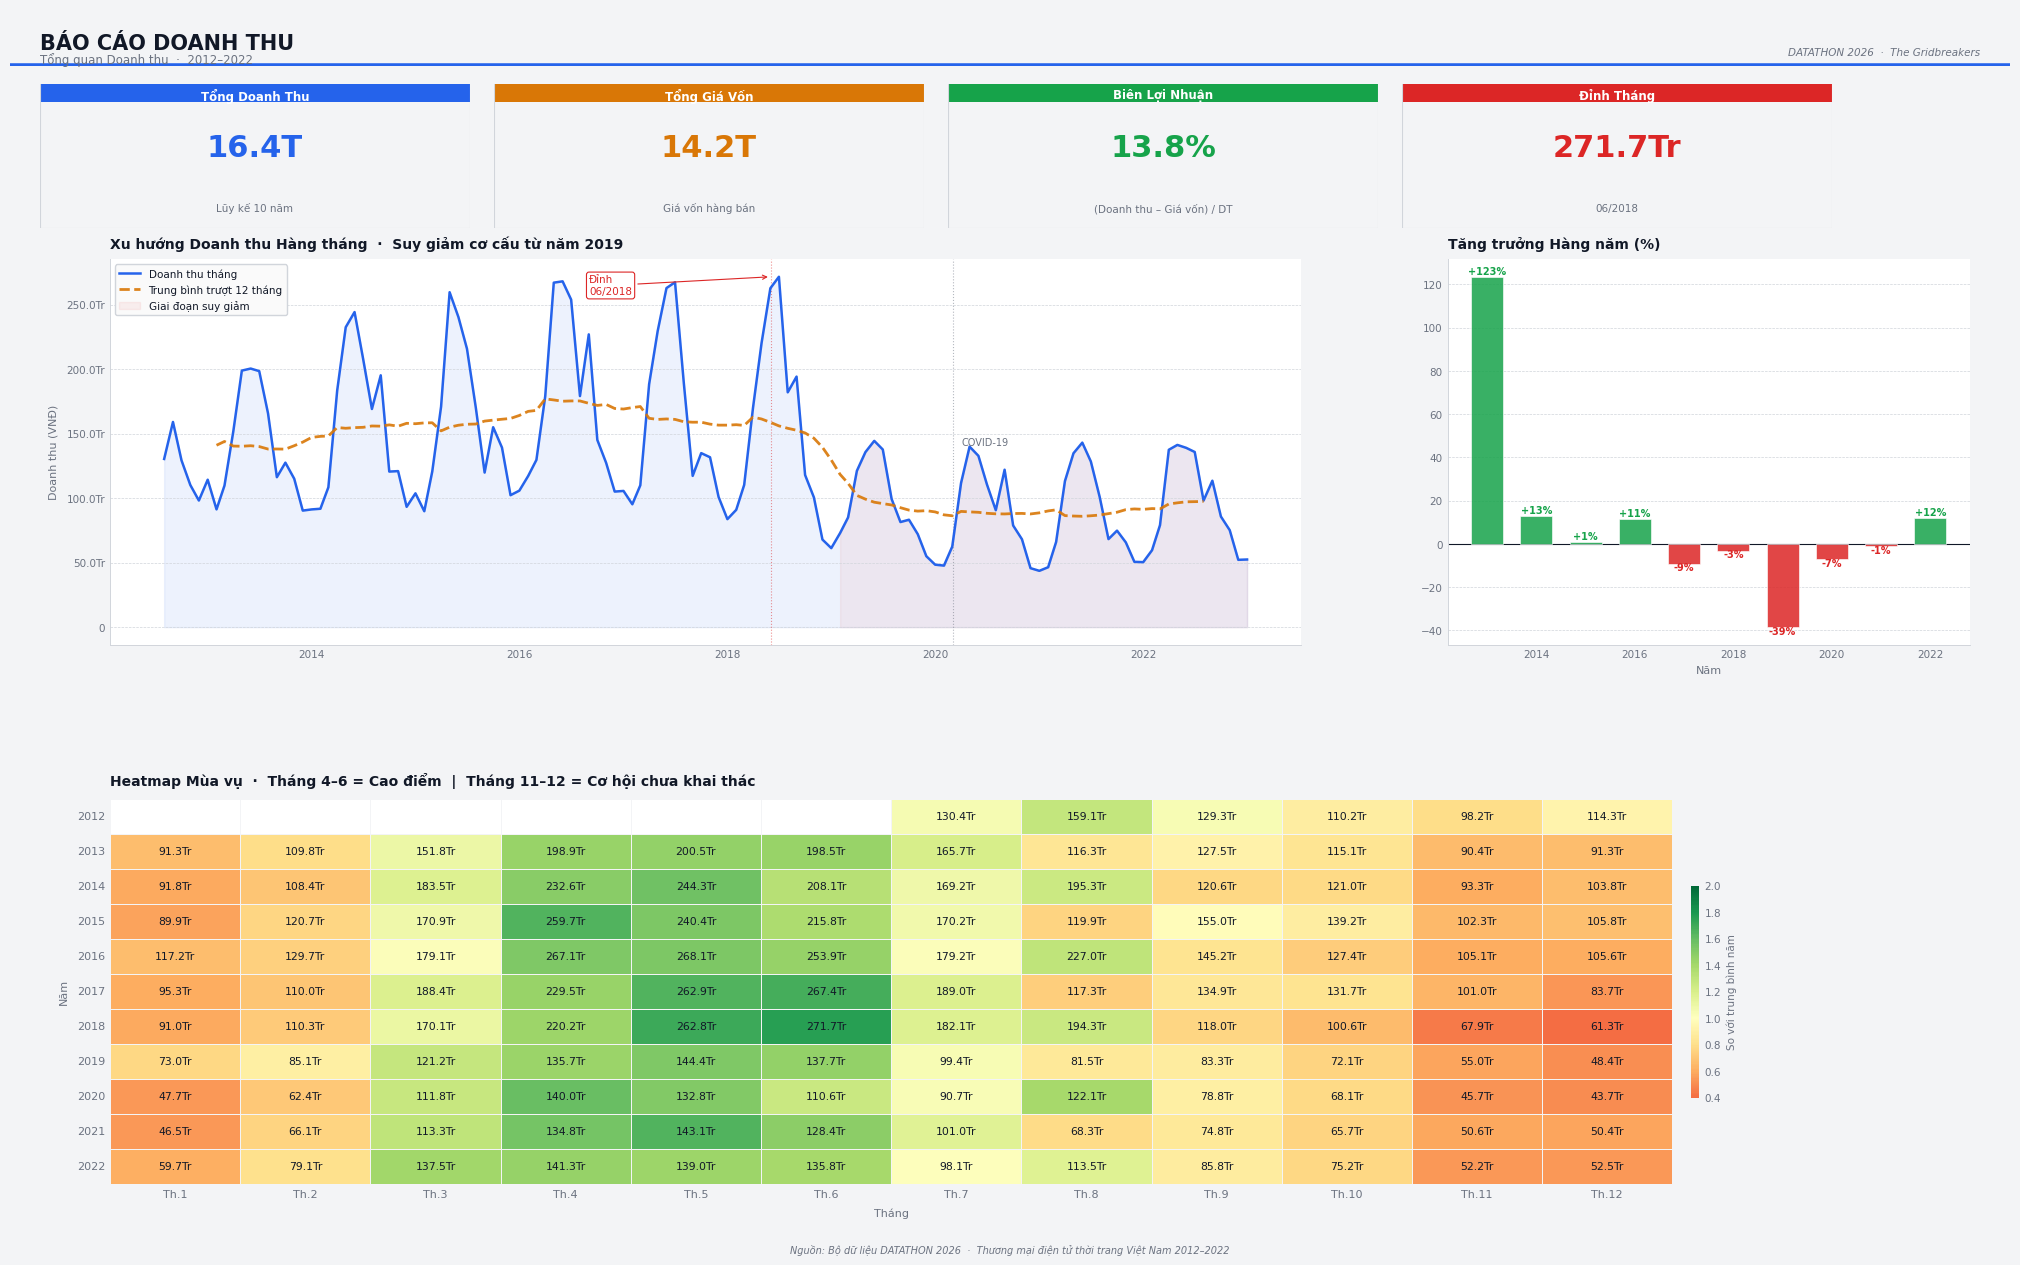

✓ Dashboard 1 (tiếng Việt có dấu) đã lưu!


In [4]:
sales = dfs["sales.csv"].copy()
sales["year"]  = sales["Date"].dt.year
sales["month"] = sales["Date"].dt.month

monthly = sales.set_index("Date")["Revenue"].resample("ME").sum()
yearly  = sales.groupby("year")["Revenue"].sum()
total_r = sales["Revenue"].sum()
total_c = sales["COGS"].sum()
margin  = (total_r - total_c) / total_r * 100
roll12  = monthly.rolling(12, center=True).mean()
yoy     = yearly.pct_change() * 100

WHITE   = "#FFFFFF"
BG_PAGE = "#F3F4F6"
BG_PLOT = "#FAFAFA"
BLUE    = "#2563EB"
GREEN   = "#16A34A"
ORANGE  = "#D97706"
RED     = "#DC2626"
GRAY1   = "#111827"
GRAY2   = "#6B7280"
GRAY3   = "#D1D5DB"

import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from pathlib import Path

CHARTS_DIR = Path("./charts")
CHARTS_DIR.mkdir(exist_ok=True)

def M(x, _=None):
    if x is None: return ""
    x = float(x)
    if abs(x) >= 1e9:  return f"{x/1e9:.1f}T"
    if abs(x) >= 1e6:  return f"{x/1e6:.1f}Tr"
    if abs(x) >= 1e3:  return f"{x/1e3:.0f}N"
    return f"{x:.0f}"

plt.rcParams.update({
    "font.family":       "DejaVu Sans",
    "figure.facecolor":  BG_PAGE,
    "axes.facecolor":    BG_PLOT,
    "axes.edgecolor":    GRAY3,
    "axes.linewidth":    0.7,
    "axes.labelcolor":   GRAY2,
    "axes.titlesize":    10,
    "axes.titleweight":  "bold",
    "axes.titlepad":     8,
    "axes.labelsize":    8,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "xtick.labelsize":   7.5,
    "ytick.labelsize":   7.5,
    "xtick.color":       GRAY2,
    "ytick.color":       GRAY2,
    "xtick.major.size":  0,
    "ytick.major.size":  0,
    "grid.color":        GRAY3,
    "grid.linewidth":    0.5,
    "grid.linestyle":    "--",
    "legend.fontsize":   7.5,
    "legend.framealpha": 1.0,
    "legend.edgecolor":  GRAY3,
    "text.color":        GRAY1,
})

fig = plt.figure(figsize=(20, 12.5), facecolor=BG_PAGE)

# Header
header = fig.add_axes([0, 0.955, 1, 0.045])
header.set_facecolor(WHITE)
header.set_axis_off()
header.axhline(0, color=BLUE, linewidth=4)
fig.text(0.015, 0.973, "BÁO CÁO DOANH THU", fontsize=15,
         fontweight="bold", color=GRAY1, va="center")
fig.text(0.015, 0.960, "Tổng quan Doanh thu  ·  2012–2022",
         fontsize=8.5, color=GRAY2, va="center")
fig.text(0.985, 0.966, "DATATHON 2026  ·  The Gridbreakers",
         fontsize=7.5, color=GRAY2, ha="right", va="center", style="italic")

# KPI Cards
kpi_data = [
    ("Tổng Doanh Thu",  M(total_r),       "Lũy kế 10 năm",               BLUE,   "#EFF6FF"),
    ("Tổng Giá Vốn",    M(total_c),       "Giá vốn hàng bán",             ORANGE, "#FFFBEB"),
    ("Biên Lợi Nhuận",  f"{margin:.1f}%", "(Doanh thu – Giá vốn) / DT",  GREEN,  "#F0FDF4"),
    ("Đỉnh Tháng",      M(monthly.max()), monthly.idxmax().strftime("%m/%Y"), RED, "#FFF1F2"),
]

card_w, card_h = 0.215, 0.115
card_top  = 0.825
card_gaps = [0.015, 0.242, 0.469, 0.696]

for (label, value, sub, col, bg), x0 in zip(kpi_data, card_gaps):
    ax_c = fig.add_axes([x0, card_top, card_w, card_h])
    ax_c.set_facecolor(bg)
    ax_c.set_xlim(0, 1); ax_c.set_ylim(0, 1)
    ax_c.set_axis_off()
    ax_c.add_patch(mpatches.FancyBboxPatch(
        (0, 0.88), 1, 0.12, boxstyle="square,pad=0",
        facecolor=col, linewidth=0,
        transform=ax_c.transAxes, clip_on=False))
    for side, kw in [
        ("bottom", dict(y=0, xmin=0, xmax=1)),
        ("left",   dict(x=0, ymin=0, ymax=1)),
        ("right",  dict(x=1, ymin=0, ymax=1)),
    ]:
        if side == "bottom":
            ax_c.axhline(linewidth=0.8, color=GRAY3, **kw)
        else:
            ax_c.axvline(linewidth=0.8, color=GRAY3, **kw)
    ax_c.text(0.5, 0.97, label, ha="center", va="top",
              fontsize=8.5, color=WHITE, fontweight="600",
              transform=ax_c.transAxes)
    ax_c.text(0.5, 0.56, value, ha="center", va="center",
              fontsize=22, fontweight="bold", color=col,
              transform=ax_c.transAxes)
    ax_c.text(0.5, 0.10, sub, ha="center", va="bottom",
              fontsize=7.5, color=GRAY2,
              transform=ax_c.transAxes)

gs = gridspec.GridSpec(2, 3, figure=fig,
    top=0.80, bottom=0.06,
    left=0.05, right=0.98,
    hspace=0.40, wspace=0.28)

# Chart 1: Xu hướng Doanh thu Hàng tháng
ax1 = fig.add_subplot(gs[0, :2])
ax1.set_facecolor(WHITE)
ax1.fill_between(monthly.index, monthly.values, alpha=0.08, color=BLUE)
ax1.plot(monthly.index, monthly.values,
         color=BLUE, lw=1.8, label="Doanh thu tháng", zorder=3)
ax1.plot(roll12.index, roll12.values,
         color=ORANGE, lw=2, ls="--",
         label="Trung bình trượt 12 tháng", zorder=3, alpha=0.9)
mask = monthly.index >= pd.Timestamp("2019-01-01")
ax1.fill_between(monthly.index, monthly.values,
                 where=mask, alpha=0.06, color=RED,
                 label="Giai đoạn suy giảm")
ax1.axvline(pd.Timestamp("2018-06-01"), color=RED, lw=0.8, ls=":", alpha=0.5, zorder=2)
ax1.annotate("Đỉnh\n06/2018",
    xy=(pd.Timestamp("2018-06-01"), monthly.max()),
    xytext=(pd.Timestamp("2016-09-01"), monthly.max()*0.95),
    fontsize=7.5, color=RED,
    arrowprops=dict(arrowstyle="->", color=RED, lw=0.8),
    bbox=dict(boxstyle="round,pad=0.25", fc=WHITE, ec=RED, lw=0.8))
ax1.axvline(pd.Timestamp("2020-03-01"), color=GRAY2, lw=0.8, ls=":", alpha=0.5, zorder=2)
ax1.text(pd.Timestamp("2020-04-01"), monthly.max()*0.52, "COVID-19", fontsize=7, color=GRAY2)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(M))
ax1.set_title("Xu hướng Doanh thu Hàng tháng  ·  Suy giảm cơ cấu từ năm 2019",
              loc="left", color=GRAY1)
ax1.set_xlabel("")
ax1.set_ylabel("Doanh thu (VNĐ)", labelpad=6)
ax1.legend(loc="upper left", frameon=True, fontsize=7.5)
ax1.grid(axis="y", zorder=0)
ax1.spines["left"].set_color(GRAY3)
ax1.spines["bottom"].set_color(GRAY3)

# Chart 2: Tăng trưởng Hàng năm
ax2 = fig.add_subplot(gs[0, 2])
ax2.set_facecolor(WHITE)
yoy_d = yoy.dropna()
bar_colors = [GREEN if v >= 0 else RED for v in yoy_d.values]
ax2.bar(yoy_d.index, yoy_d.values,
        color=bar_colors, alpha=0.85, width=0.65,
        edgecolor=WHITE, linewidth=0.5, zorder=3)
ax2.axhline(0, color=GRAY1, lw=0.8, zorder=2)
for yr, val in yoy_d.items():
    offset = 1.2 if val >= 0 else -3.2
    ax2.text(yr, val + offset, f"{val:+.0f}%",
             ha="center", fontsize=7,
             color=GREEN if val >= 0 else RED, fontweight="600")
ax2.set_title("Tăng trưởng Hàng năm (%)", loc="left", color=GRAY1)
ax2.set_xlabel("Năm")
ax2.set_ylabel("")
ax2.grid(axis="y", zorder=0)
ax2.spines["left"].set_color(GRAY3)
ax2.spines["bottom"].set_color(GRAY3)

# Chart 3: Heatmap Mùa vụ
ax3 = fig.add_subplot(gs[1, :])
ax3.set_facecolor(WHITE)
pivot = sales.pivot_table(
    values="Revenue", index="year", columns="month", aggfunc="sum")
pivot.columns = ["Th.1","Th.2","Th.3","Th.4","Th.5","Th.6",
                 "Th.7","Th.8","Th.9","Th.10","Th.11","Th.12"]
pivot_n = pivot.div(pivot.mean(axis=1), axis=0)
try:
    annot_df = pivot.map(M)
except AttributeError:
    annot_df = pivot.applymap(M)
sns.heatmap(
    pivot_n, ax=ax3,
    cmap="RdYlGn", center=1.0, vmin=0.4, vmax=2.0,
    annot=annot_df, fmt="",
    linewidths=0.4, linecolor=BG_PAGE,
    annot_kws={"size": 7.8, "color": GRAY1, "fontweight": "500"},
    cbar_kws={"label": "So với trung bình năm", "shrink": 0.55, "aspect": 25, "pad": 0.01}
)
ax3.set_title(
    "Heatmap Mùa vụ  ·  Tháng 4–6 = Cao điểm  |  Tháng 11–12 = Cơ hội chưa khai thác",
    loc="left", color=GRAY1, fontsize=10, fontweight="bold", pad=10)
ax3.set_xlabel("Tháng", labelpad=6)
ax3.set_ylabel("Năm", labelpad=6)
ax3.tick_params(axis="both", length=0, labelsize=8)
ax3.set_yticklabels(ax3.get_yticklabels(), rotation=0)
cbar = ax3.collections[0].colorbar
cbar.ax.tick_params(labelsize=7.5)
cbar.ax.yaxis.label.set_size(7.5)

# Footer
fig.text(0.5, 0.005,
         "Nguồn: Bộ dữ liệu DATATHON 2026  ·  Thương mại điện tử thời trang Việt Nam 2012–2022",
         ha="center", fontsize=7, color=GRAY2, style="italic")

plt.savefig(
    CHARTS_DIR / "dashboard1_revenue_overview.png",
    dpi=150, bbox_inches="tight", facecolor=BG_PAGE)
plt.show()
print("✓ Dashboard 1 (tiếng Việt có dấu) đã lưu!")

---
## DASHBOARD 2 — Phân tích Sản phẩm & Danh mục
**Cấp độ: Descriptive + Diagnostic**


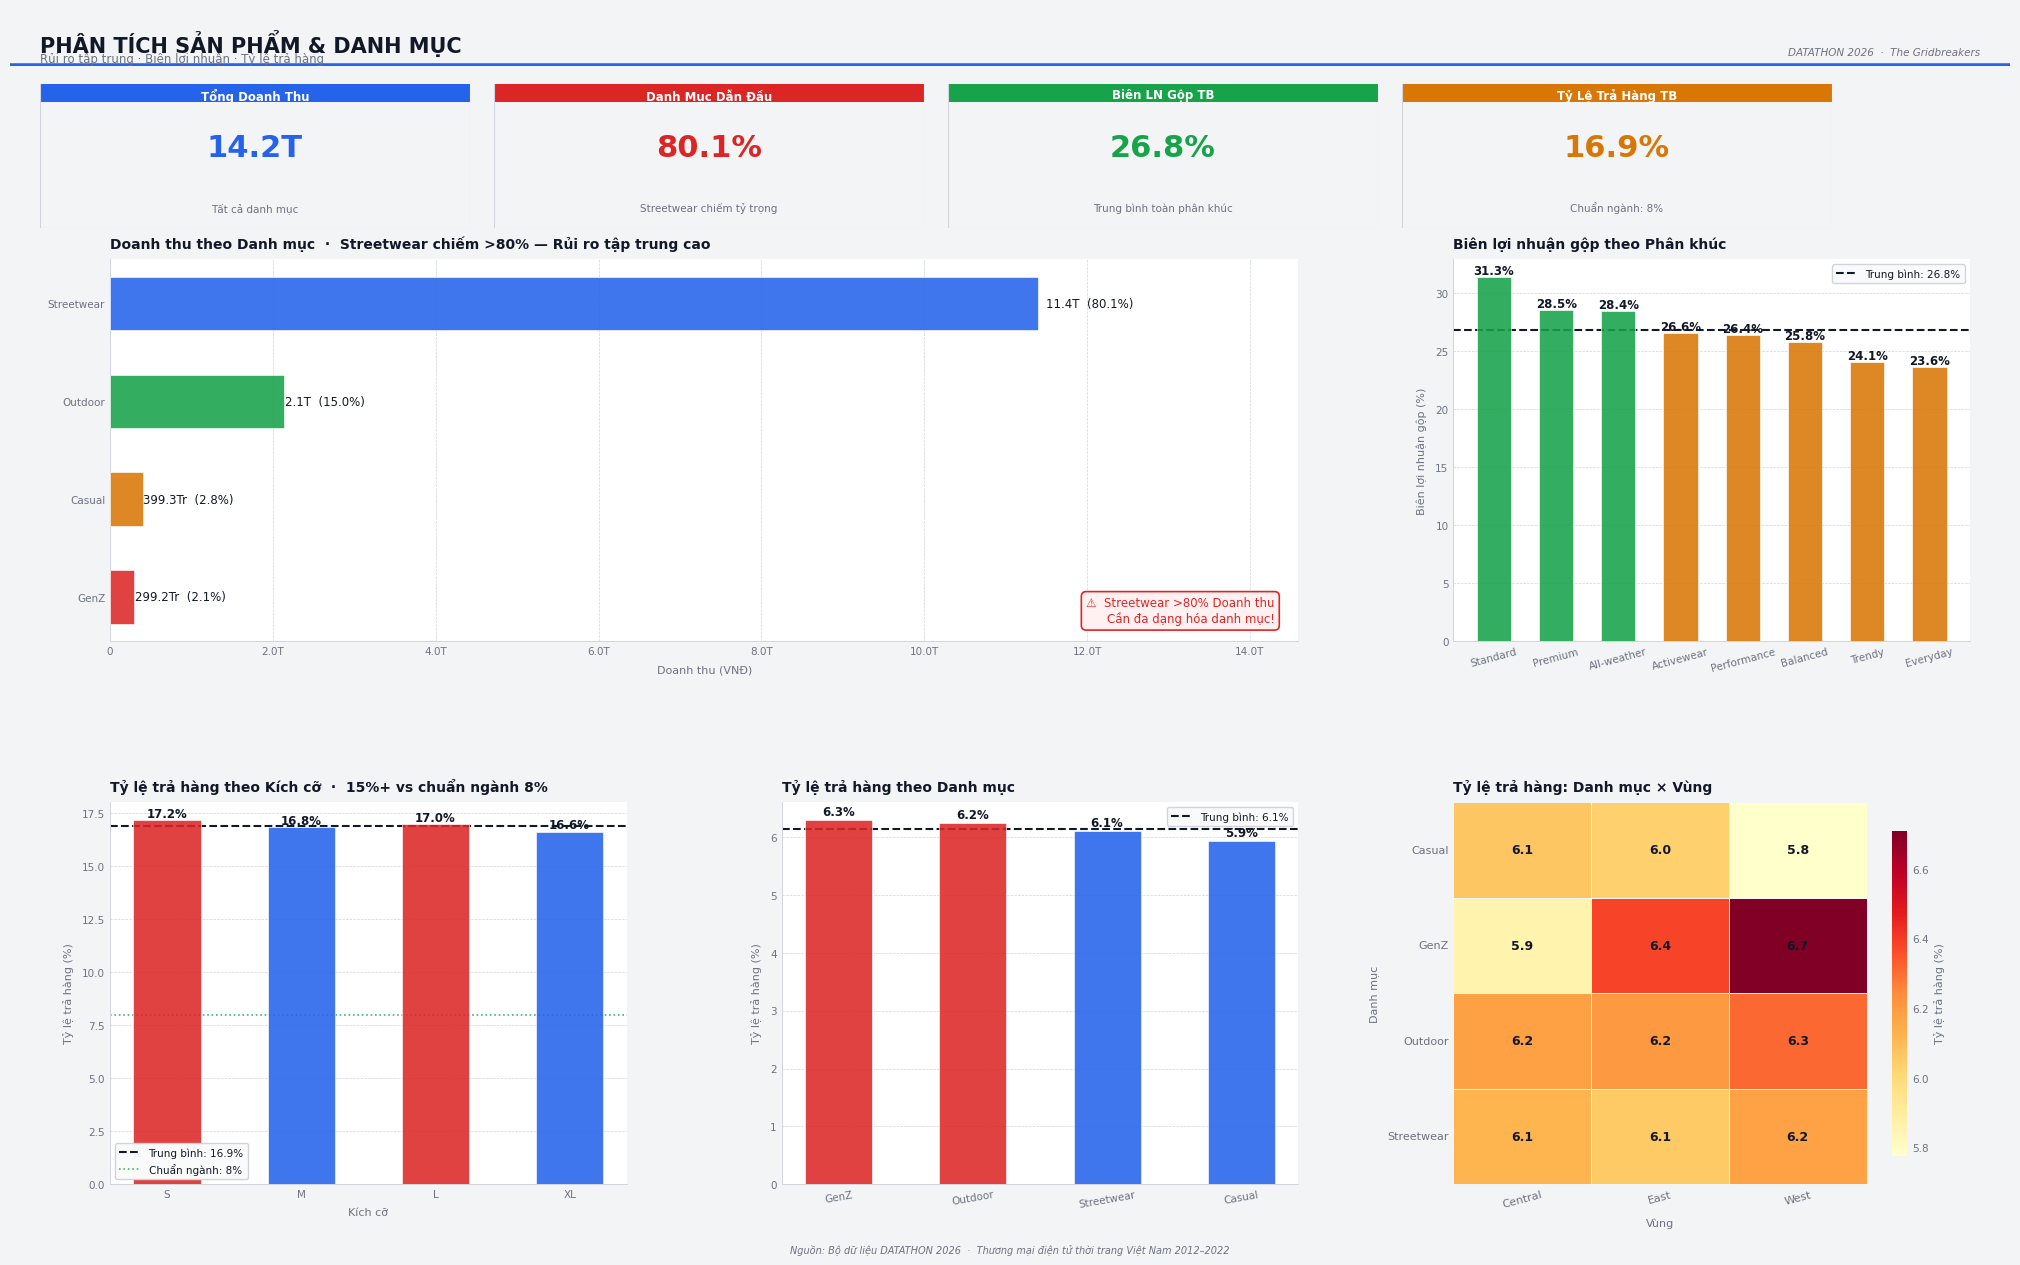

✓ Dashboard 2 (đồng bộ style) đã lưu!


In [5]:
items    = dfs["order_items.csv"].copy()
products = dfs["products.csv"].copy()
orders   = dfs["orders.csv"].copy()
returns  = dfs["returns.csv"].copy()
geo      = dfs["geography.csv"].copy()

items_p = (
    items
    .merge(products[["product_id","category","segment","size","price","cogs"]],
           on="product_id", how="left")
    .merge(orders[["order_id","order_status","zip"]], on="order_id", how="left")
    .merge(geo[["zip","region"]], on="zip", how="left")
)
items_p = items_p[items_p["order_status"] != "cancelled"]
items_p["line_rev"] = (items_p["quantity"] * items_p["unit_price"]
                       - items_p["discount_amount"].fillna(0))

cat_rev    = items_p.groupby("category")["line_rev"].sum().sort_values(ascending=False)
seg_margin = (products.groupby("segment")
              .apply(lambda d: ((d["price"] - d["cogs"]) / d["price"]).mean() * 100)
              .sort_values(ascending=False))

ret_p = (
    returns
    .merge(products[["product_id","category","size"]], on="product_id", how="left")
    .merge(orders[["order_id","zip"]], on="order_id", how="left")
    .merge(geo[["zip","region"]], on="zip", how="left")
)

sz    = ["S","M","L","XL"]
sz_i  = items_p[items_p["size"].isin(sz)].groupby("size")["order_id"].count().reindex(sz)
sz_r  = ret_p[ret_p["size"].isin(sz)].groupby("size")["return_quantity"].sum().reindex(sz)
sz_rt = (sz_r / sz_i * 100).fillna(0)

cat_i  = items_p.groupby("category")["order_id"].count()
cat_rt = (ret_p.groupby("category")["return_quantity"].count() / cat_i * 100).dropna()
cat_rt = cat_rt.sort_values(ascending=False)

# ── Màu Power BI — đồng bộ Dashboard 1 ──────────────────
WHITE   = "#FFFFFF"
BG_PAGE = "#F3F4F6"
BG_PLOT = "#FAFAFA"
BLUE    = "#2563EB"
GREEN   = "#16A34A"
ORANGE  = "#D97706"
RED     = "#DC2626"
PURPLE  = "#7C3AED"
TEAL    = "#0891B2"
GRAY1   = "#111827"
GRAY2   = "#6B7280"
GRAY3   = "#D1D5DB"
BAR_PAL = [BLUE, GREEN, ORANGE, RED, PURPLE, TEAL, "#DB2777"]

import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from pathlib import Path

CHARTS_DIR = Path("./charts")
CHARTS_DIR.mkdir(exist_ok=True)

def M(x, _=None):
    if x is None: return ""
    x = float(x)
    if abs(x) >= 1e9: return f"{x/1e9:.1f}T"
    if abs(x) >= 1e6: return f"{x/1e6:.1f}Tr"
    if abs(x) >= 1e3: return f"{x/1e3:.0f}N"
    return f"{x:.0f}"

def style_ax(ax):
    ax.set_facecolor(WHITE)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color(GRAY3)
    ax.spines["bottom"].set_color(GRAY3)
    ax.tick_params(length=0)
    ax.xaxis.label.set_color(GRAY2)
    ax.yaxis.label.set_color(GRAY2)

plt.rcParams.update({
    "font.family":       "DejaVu Sans",
    "figure.facecolor":  BG_PAGE,
    "axes.facecolor":    BG_PLOT,
    "axes.edgecolor":    GRAY3,
    "axes.linewidth":    0.7,
    "axes.labelcolor":   GRAY2,
    "axes.titlesize":    10,
    "axes.titleweight":  "bold",
    "axes.titlepad":     8,
    "axes.labelsize":    8,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "xtick.labelsize":   7.5,
    "ytick.labelsize":   7.5,
    "xtick.color":       GRAY2,
    "ytick.color":       GRAY2,
    "xtick.major.size":  0,
    "ytick.major.size":  0,
    "grid.color":        GRAY3,
    "grid.linewidth":    0.5,
    "grid.linestyle":    "--",
    "legend.fontsize":   7.5,
    "legend.framealpha": 1.0,
    "legend.edgecolor":  GRAY3,
    "text.color":        GRAY1,
})

# ── KPI tổng hợp ─────────────────────────────────────────
total_rev    = cat_rev.sum()
top_cat      = cat_rev.index[0]
top_cat_pct  = cat_rev.iloc[0] / total_rev * 100
avg_margin   = seg_margin.mean()
avg_ret_sz   = sz_rt.mean()

# ── Layout ────────────────────────────────────────────────
fig = plt.figure(figsize=(20, 12.5), facecolor=BG_PAGE)

# Header — đồng bộ Dashboard 1
header = fig.add_axes([0, 0.955, 1, 0.045])
header.set_facecolor(WHITE)
header.set_axis_off()
header.axhline(0, color=BLUE, linewidth=4)
fig.text(0.015, 0.973, "PHÂN TÍCH SẢN PHẨM & DANH MỤC", fontsize=15,
         fontweight="bold", color=GRAY1, va="center")
fig.text(0.015, 0.960, "Rủi ro tập trung · Biên lợi nhuận · Tỷ lệ trả hàng",
         fontsize=8.5, color=GRAY2, va="center")
fig.text(0.985, 0.966, "DATATHON 2026  ·  The Gridbreakers",
         fontsize=7.5, color=GRAY2, ha="right", va="center", style="italic")

# ── KPI Cards ─────────────────────────────────────────────
kpi_data = [
    ("Tổng Doanh Thu",      M(total_rev),          "Tất cả danh mục",            BLUE,   "#EFF6FF"),
    ("Danh Mục Dẫn Đầu",    f"{top_cat_pct:.1f}%", f"{top_cat} chiếm tỷ trọng", RED,    "#FFF1F2"),
    ("Biên LN Gộp TB",      f"{avg_margin:.1f}%",  "Trung bình toàn phân khúc",  GREEN,  "#F0FDF4"),
    ("Tỷ Lệ Trả Hàng TB",   f"{avg_ret_sz:.1f}%",  "Chuẩn ngành: 8%",            ORANGE, "#FFFBEB"),
]

card_w, card_h = 0.215, 0.115
card_top  = 0.825
card_gaps = [0.015, 0.242, 0.469, 0.696]

for (label, value, sub, col, bg), x0 in zip(kpi_data, card_gaps):
    ax_c = fig.add_axes([x0, card_top, card_w, card_h])
    ax_c.set_facecolor(bg)
    ax_c.set_xlim(0, 1); ax_c.set_ylim(0, 1)
    ax_c.set_axis_off()
    ax_c.add_patch(mpatches.FancyBboxPatch(
        (0, 0.88), 1, 0.12, boxstyle="square,pad=0",
        facecolor=col, linewidth=0,
        transform=ax_c.transAxes, clip_on=False))
    for side, kw in [
        ("bottom", dict(y=0, xmin=0, xmax=1)),
        ("left",   dict(x=0, ymin=0, ymax=1)),
        ("right",  dict(x=1, ymin=0, ymax=1)),
    ]:
        if side == "bottom":
            ax_c.axhline(linewidth=0.8, color=GRAY3, **kw)
        else:
            ax_c.axvline(linewidth=0.8, color=GRAY3, **kw)
    ax_c.text(0.5, 0.97, label, ha="center", va="top",
              fontsize=8.5, color=WHITE, fontweight="600",
              transform=ax_c.transAxes)
    ax_c.text(0.5, 0.56, value, ha="center", va="center",
              fontsize=22, fontweight="bold", color=col,
              transform=ax_c.transAxes)
    ax_c.text(0.5, 0.10, sub, ha="center", va="bottom",
              fontsize=7.5, color=GRAY2,
              transform=ax_c.transAxes)

# ── Grid charts ───────────────────────────────────────────
gs = gridspec.GridSpec(2, 3, figure=fig,
    top=0.80, bottom=0.06,
    left=0.05, right=0.98,
    hspace=0.42, wspace=0.30)

# ── Chart 1: Doanh thu theo Danh mục (horizontal bar) ────
ax1 = fig.add_subplot(gs[0, :2])
style_ax(ax1)
share  = cat_rev / cat_rev.sum() * 100
colors = [BAR_PAL[i % len(BAR_PAL)] for i in range(len(cat_rev))]
bars   = ax1.barh(cat_rev.index[::-1], cat_rev.values[::-1],
                  color=colors[::-1], alpha=0.88, height=0.55,
                  edgecolor=WHITE, linewidth=0.5, zorder=3)
for bar, (cat, val) in zip(bars, cat_rev[::-1].items()):
    ax1.text(bar.get_width() * 1.008,
             bar.get_y() + bar.get_height() / 2,
             f"{M(val)}  ({share[cat]:.1f}%)",
             va="center", fontsize=8.5, color=GRAY1, fontweight="500")
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(M))
ax1.set_xlim(0, cat_rev.max() * 1.28)
ax1.set_title("Doanh thu theo Danh mục  ·  Streetwear chiếm >80% — Rủi ro tập trung cao",
              loc="left", color=GRAY1)
ax1.set_xlabel("Doanh thu (VNĐ)", labelpad=6)
ax1.grid(axis="x", zorder=0)
ax1.grid(axis="y", visible=False)
# Alert box
ax1.text(0.98, 0.05,
         "⚠  Streetwear >80% Doanh thu\n    Cần đa dạng hóa danh mục!",
         transform=ax1.transAxes, ha="right", fontsize=8.5, color=RED,
         bbox=dict(boxstyle="round,pad=0.4", fc="#FFF1F2", ec=RED, lw=1.2))

# ── Chart 2: Biên lợi nhuận theo Phân khúc ───────────────
ax2 = fig.add_subplot(gs[0, 2])
style_ax(ax2)
avg_m  = seg_margin.mean()
cols_s = [GREEN if v >= avg_m else ORANGE for v in seg_margin.values]
bars2  = ax2.bar(seg_margin.index, seg_margin.values,
                 color=cols_s, alpha=0.88, width=0.55,
                 edgecolor=WHITE, linewidth=0.5, zorder=3)
ax2.axhline(avg_m, color=GRAY1, lw=1.5, ls="--", zorder=2,
            label=f"Trung bình: {avg_m:.1f}%")
for b, v in zip(bars2, seg_margin.values):
    ax2.text(b.get_x() + b.get_width() / 2,
             b.get_height() + 0.25,
             f"{v:.1f}%", ha="center", fontsize=8.5,
             fontweight="bold", color=GRAY1)
ax2.set_title("Biên lợi nhuận gộp theo Phân khúc", loc="left", color=GRAY1)
ax2.set_ylabel("Biên lợi nhuận gộp (%)", labelpad=6)
ax2.tick_params(axis="x", rotation=15)
ax2.legend(fontsize=7.5)
ax2.grid(axis="y", zorder=0)

# ── Chart 3: Tỷ lệ trả hàng theo Kích cỡ ────────────────
ax3 = fig.add_subplot(gs[1, 0])
style_ax(ax3)
cols_sz = [RED if r > sz_rt.mean() else BLUE for r in sz_rt.values]
b3 = ax3.bar(sz_rt.index, sz_rt.values,
             color=cols_sz, alpha=0.88, width=0.5,
             edgecolor=WHITE, linewidth=0.5, zorder=3)
ax3.axhline(sz_rt.mean(), color=GRAY1, lw=1.5, ls="--", zorder=2,
            label=f"Trung bình: {sz_rt.mean():.1f}%")
ax3.axhline(8, color=GREEN, lw=1.2, ls=":", alpha=0.8, zorder=2,
            label="Chuẩn ngành: 8%")
for b, v in zip(b3, sz_rt.values):
    ax3.text(b.get_x() + b.get_width() / 2,
             b.get_height() + 0.15,
             f"{v:.1f}%", ha="center", fontsize=8.5,
             fontweight="bold", color=GRAY1)
ax3.set_title("Tỷ lệ trả hàng theo Kích cỡ  ·  15%+ vs chuẩn ngành 8%",
              loc="left", color=GRAY1)
ax3.set_ylabel("Tỷ lệ trả hàng (%)", labelpad=6)
ax3.set_xlabel("Kích cỡ", labelpad=6)
ax3.legend(fontsize=7.5)
ax3.grid(axis="y", zorder=0)

# ── Chart 4: Tỷ lệ trả hàng theo Danh mục ───────────────
ax4 = fig.add_subplot(gs[1, 1])
style_ax(ax4)
cols_cr = [RED if r > cat_rt.mean() else BLUE for r in cat_rt.values]
b4 = ax4.bar(cat_rt.index, cat_rt.values,
             color=cols_cr, alpha=0.88, width=0.5,
             edgecolor=WHITE, linewidth=0.5, zorder=3)
ax4.axhline(cat_rt.mean(), color=GRAY1, lw=1.5, ls="--", zorder=2,
            label=f"Trung bình: {cat_rt.mean():.1f}%")
for i, (c, v) in enumerate(cat_rt.items()):
    ax4.text(i, v + 0.08, f"{v:.1f}%",
             ha="center", fontsize=8.5,
             fontweight="bold", color=GRAY1)
ax4.set_title("Tỷ lệ trả hàng theo Danh mục", loc="left", color=GRAY1)
ax4.set_ylabel("Tỷ lệ trả hàng (%)", labelpad=6)
ax4.tick_params(axis="x", rotation=10)
ax4.legend(fontsize=7.5)
ax4.grid(axis="y", zorder=0)

# ── Chart 5: Heatmap Danh mục × Vùng ────────────────────
ax5 = fig.add_subplot(gs[1, 2])
style_ax(ax5)
cr_i  = items_p.groupby(["category","region"])["order_id"].count().unstack(fill_value=1)
cr_r  = ret_p.groupby(["category","region"])["return_quantity"].count().unstack(fill_value=0)
cr_rt = (cr_r / cr_i * 100).fillna(0)
sns.heatmap(cr_rt, ax=ax5,
            annot=True, fmt=".1f", cmap="YlOrRd",
            linewidths=0.4, linecolor=BG_PAGE,
            annot_kws={"size": 9, "color": GRAY1, "fontweight": "600"},
            cbar_kws={"label": "Tỷ lệ trả hàng (%)", "shrink": 0.85, "aspect": 22})
ax5.set_title("Tỷ lệ trả hàng: Danh mục × Vùng", loc="left", color=GRAY1)
ax5.set_xlabel("Vùng", labelpad=6)
ax5.set_ylabel("Danh mục", labelpad=6)
ax5.tick_params(length=0, labelsize=8)
ax5.set_yticklabels(ax5.get_yticklabels(), rotation=0)
ax5.set_xticklabels(ax5.get_xticklabels(), rotation=15)

# Footer
fig.text(0.5, 0.005,
         "Nguồn: Bộ dữ liệu DATATHON 2026  ·  Thương mại điện tử thời trang Việt Nam 2012–2022",
         ha="center", fontsize=7, color=GRAY2, style="italic")

plt.savefig(CHARTS_DIR / "dashboard2_product_analysis.png",
            dpi=150, bbox_inches="tight", facecolor=BG_PAGE)
plt.show()
print("✓ Dashboard 2 (đồng bộ style) đã lưu!")

---
## DASHBOARD 3 — Phân tích Khách hàng
**Cấp độ: Descriptive + Diagnostic + Prescriptive**


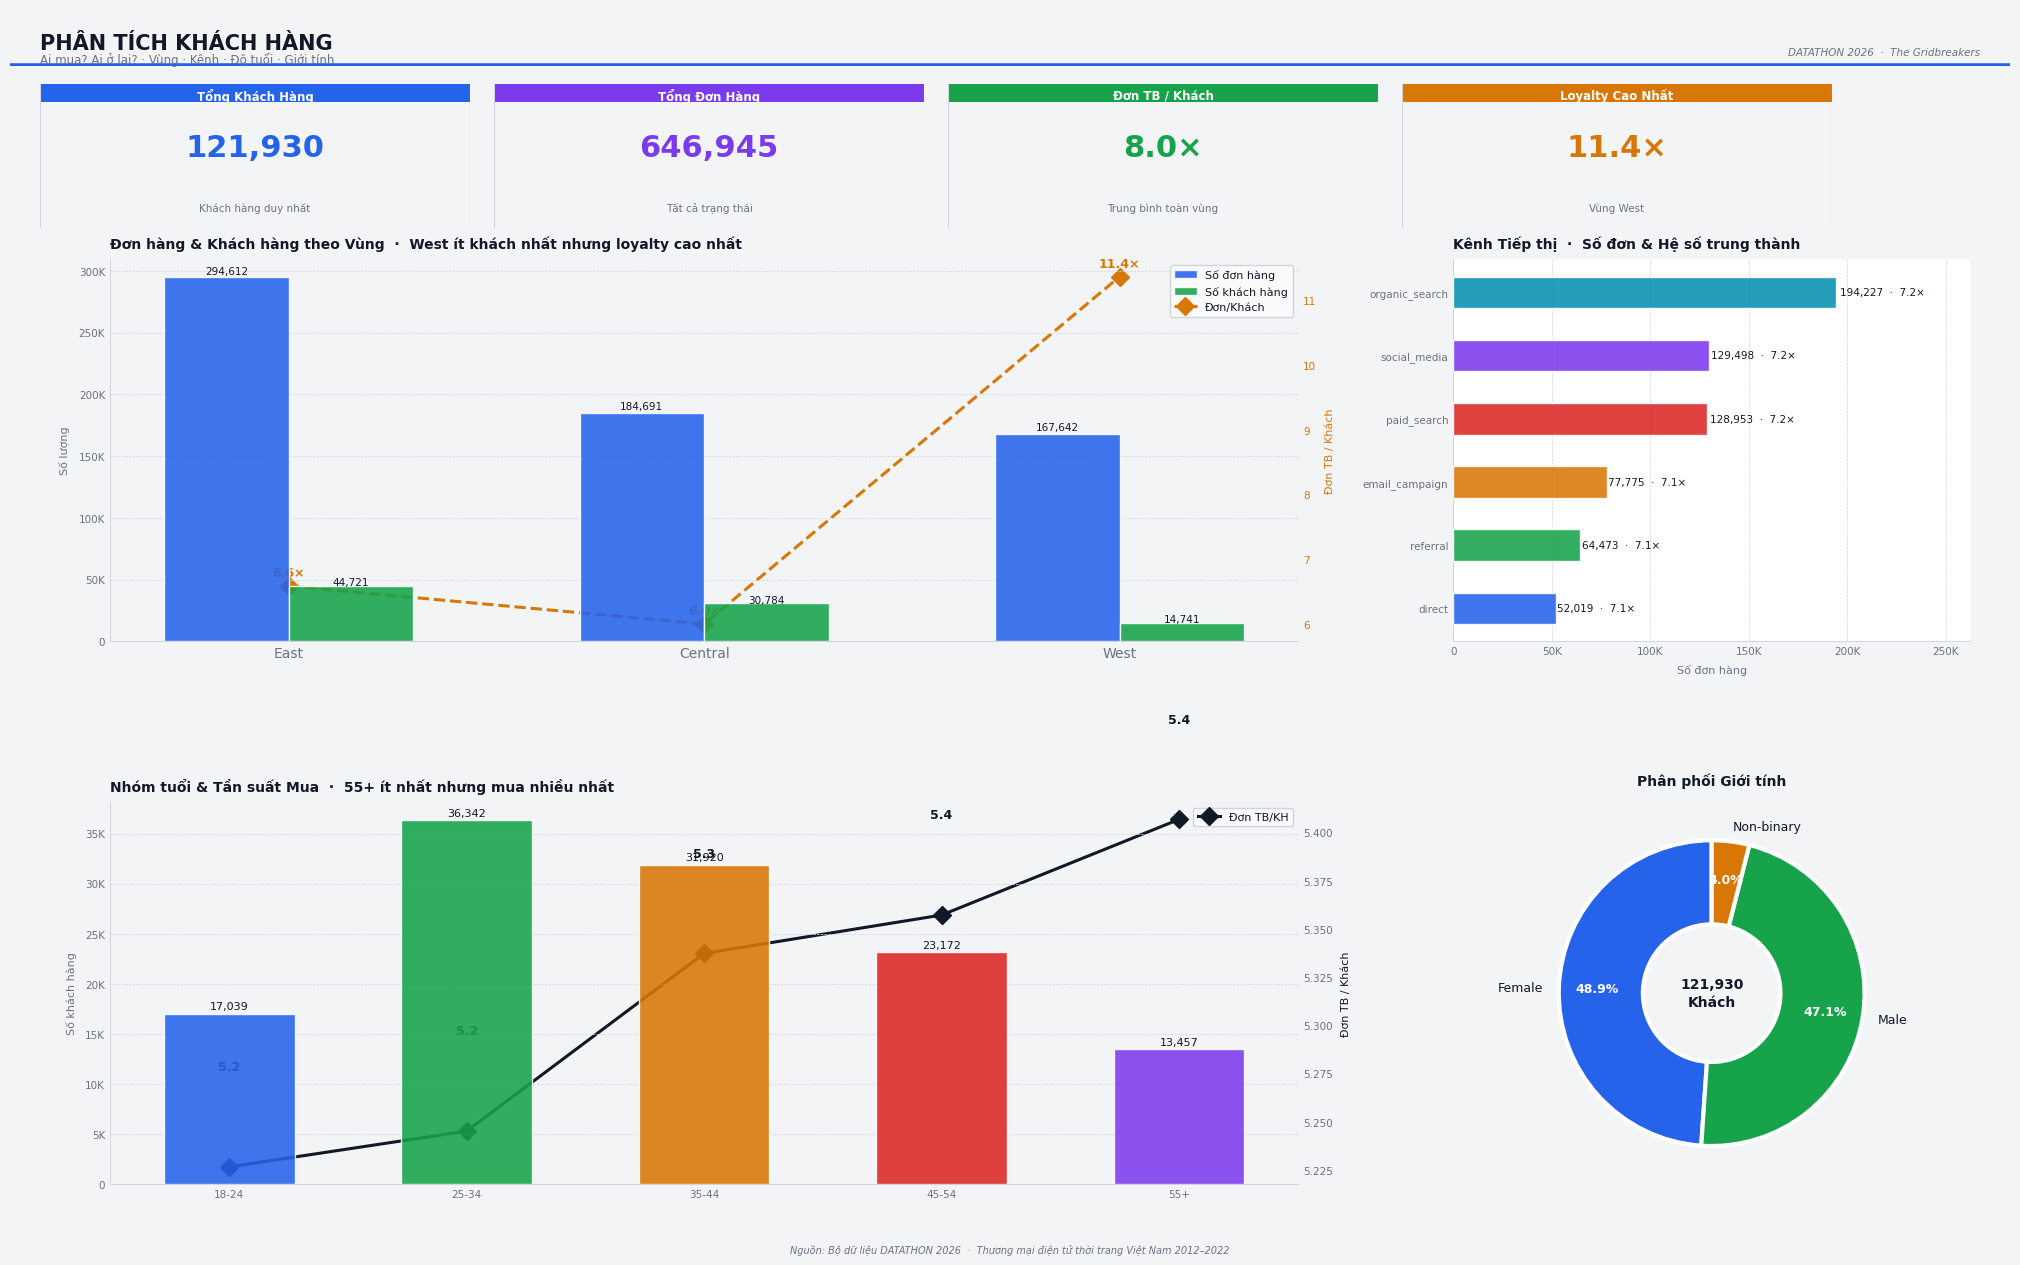

✓ Dashboard 3 (đồng bộ style) đã lưu!


In [7]:
customers = dfs["customers.csv"].copy()
orders_d  = dfs["orders.csv"].copy()
geo_d     = dfs["geography.csv"].copy()

co = (
    orders_d
    .merge(customers[["customer_id","age_group","acquisition_channel","gender"]],
           on="customer_id", how="left")
    .merge(geo_d[["zip","region"]], on="zip", how="left")
)

reg = (co.groupby("region")
         .agg(n_orders=("order_id","count"), n_cust=("customer_id","nunique"))
         .sort_values("n_orders", ascending=False))
reg["opc"] = reg["n_orders"] / reg["n_cust"]

age_order = ["18-24","25-34","35-44","45-54","55+"]
age_cnt   = (customers[customers["age_group"].notna()]["age_group"]
             .value_counts().reindex(age_order).fillna(0))
opc_age   = (
    co[co["age_group"].notna()].groupby("age_group")["order_id"].count()
    / customers[customers["age_group"].notna()].groupby("age_group")["customer_id"].count()
).reindex(age_order).fillna(0)

acq = (co[co["acquisition_channel"].notna()]
       .groupby("acquisition_channel")
       .agg(n=("order_id","count"), nc=("customer_id","nunique")))
acq["opc"] = acq["n"] / acq["nc"]
acq = acq.sort_values("n", ascending=True)

# ── Màu Power BI — đồng bộ Dashboard 1 & 2 ──────────────
WHITE   = "#FFFFFF"
BG_PAGE = "#F3F4F6"
BG_PLOT = "#FAFAFA"
BLUE    = "#2563EB"
GREEN   = "#16A34A"
ORANGE  = "#D97706"
RED     = "#DC2626"
PURPLE  = "#7C3AED"
TEAL    = "#0891B2"
GRAY1   = "#111827"
GRAY2   = "#6B7280"
GRAY3   = "#D1D5DB"
BAR_PAL = [BLUE, GREEN, ORANGE, RED, PURPLE, TEAL, "#DB2777"]

import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

CHARTS_DIR = Path("./charts")
CHARTS_DIR.mkdir(exist_ok=True)

def M(x, _=None):
    if x is None: return ""
    x = float(x)
    if abs(x) >= 1e9: return f"{x/1e9:.1f}T"
    if abs(x) >= 1e6: return f"{x/1e6:.1f}Tr"
    if abs(x) >= 1e3: return f"{x/1e3:.0f}N"
    return f"{x:.0f}"

def style_ax(ax):
    ax.set_facecolor(WHITE)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color(GRAY3)
    ax.spines["bottom"].set_color(GRAY3)
    ax.tick_params(length=0)
    ax.xaxis.label.set_color(GRAY2)
    ax.yaxis.label.set_color(GRAY2)

plt.rcParams.update({
    "font.family":       "DejaVu Sans",
    "figure.facecolor":  BG_PAGE,
    "axes.facecolor":    BG_PLOT,
    "axes.edgecolor":    GRAY3,
    "axes.linewidth":    0.7,
    "axes.labelcolor":   GRAY2,
    "axes.titlesize":    10,
    "axes.titleweight":  "bold",
    "axes.titlepad":     8,
    "axes.labelsize":    8,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "xtick.labelsize":   7.5,
    "ytick.labelsize":   7.5,
    "xtick.color":       GRAY2,
    "ytick.color":       GRAY2,
    "xtick.major.size":  0,
    "ytick.major.size":  0,
    "grid.color":        GRAY3,
    "grid.linewidth":    0.5,
    "grid.linestyle":    "--",
    "legend.fontsize":   7.5,
    "legend.framealpha": 1.0,
    "legend.edgecolor":  GRAY3,
    "text.color":        GRAY1,
})

# ── KPI tổng hợp ─────────────────────────────────────────
total_cust    = customers["customer_id"].nunique()
total_orders  = orders_d.shape[0]
avg_opc       = reg["opc"].mean()
top_region    = reg["opc"].idxmax()
top_opc       = reg["opc"].max()

# ── Layout ────────────────────────────────────────────────
fig = plt.figure(figsize=(20, 12.5), facecolor=BG_PAGE)

# Header
header = fig.add_axes([0, 0.955, 1, 0.045])
header.set_facecolor(WHITE)
header.set_axis_off()
header.axhline(0, color=BLUE, linewidth=4)
fig.text(0.015, 0.973, "PHÂN TÍCH KHÁCH HÀNG", fontsize=15,
         fontweight="bold", color=GRAY1, va="center")
fig.text(0.015, 0.960, "Ai mua? Ai ở lại? · Vùng · Kênh · Độ tuổi · Giới tính",
         fontsize=8.5, color=GRAY2, va="center")
fig.text(0.985, 0.966, "DATATHON 2026  ·  The Gridbreakers",
         fontsize=7.5, color=GRAY2, ha="right", va="center", style="italic")

# ── KPI Cards ─────────────────────────────────────────────
kpi_data = [
    ("Tổng Khách Hàng",   f"{total_cust:,}",    "Khách hàng duy nhất",          BLUE,   "#EFF6FF"),
    ("Tổng Đơn Hàng",     f"{total_orders:,}",  "Tất cả trạng thái",            PURPLE, "#F5F3FF"),
    ("Đơn TB / Khách",    f"{avg_opc:.1f}×",    "Trung bình toàn vùng",         GREEN,  "#F0FDF4"),
    ("Loyalty Cao Nhất",  f"{top_opc:.1f}×",    f"Vùng {top_region}",           ORANGE, "#FFFBEB"),
]

card_w, card_h = 0.215, 0.115
card_top  = 0.825
card_gaps = [0.015, 0.242, 0.469, 0.696]

for (label, value, sub, col, bg), x0 in zip(kpi_data, card_gaps):
    ax_c = fig.add_axes([x0, card_top, card_w, card_h])
    ax_c.set_facecolor(bg)
    ax_c.set_xlim(0, 1); ax_c.set_ylim(0, 1)
    ax_c.set_axis_off()
    ax_c.add_patch(mpatches.FancyBboxPatch(
        (0, 0.88), 1, 0.12, boxstyle="square,pad=0",
        facecolor=col, linewidth=0,
        transform=ax_c.transAxes, clip_on=False))
    for side, kw in [
        ("bottom", dict(y=0, xmin=0, xmax=1)),
        ("left",   dict(x=0, ymin=0, ymax=1)),
        ("right",  dict(x=1, ymin=0, ymax=1)),
    ]:
        if side == "bottom":
            ax_c.axhline(linewidth=0.8, color=GRAY3, **kw)
        else:
            ax_c.axvline(linewidth=0.8, color=GRAY3, **kw)
    ax_c.text(0.5, 0.97, label, ha="center", va="top",
              fontsize=8.5, color=WHITE, fontweight="600",
              transform=ax_c.transAxes)
    ax_c.text(0.5, 0.56, value, ha="center", va="center",
              fontsize=22, fontweight="bold", color=col,
              transform=ax_c.transAxes)
    ax_c.text(0.5, 0.10, sub, ha="center", va="bottom",
              fontsize=7.5, color=GRAY2,
              transform=ax_c.transAxes)

# ── Grid charts ───────────────────────────────────────────
gs = gridspec.GridSpec(2, 3, figure=fig,
    top=0.80, bottom=0.06,
    left=0.05, right=0.98,
    hspace=0.42, wspace=0.30)

# ── Chart 1: Đơn hàng & Khách hàng theo Vùng ─────────────
ax1 = fig.add_subplot(gs[0, :2])
style_ax(ax1)
ax1b = ax1.twinx()
x = np.arange(len(reg)); w = 0.30
b1 = ax1.bar(x - w/2, reg["n_orders"], width=w, color=BLUE, alpha=0.88,
             label="Số đơn hàng", edgecolor=WHITE, zorder=3)
b2 = ax1.bar(x + w/2, reg["n_cust"],   width=w, color=GREEN, alpha=0.88,
             label="Số khách hàng", edgecolor=WHITE, zorder=3)
ax1b.plot(x, reg["opc"], "D--", color=ORANGE, lw=2.2, markersize=9,
          label="Đơn/Khách", zorder=4)

for i, (_, row) in enumerate(reg.iterrows()):
    ax1.text(i - w/2, row["n_orders"] + reg["n_orders"].max()*0.01,
             f"{row['n_orders']:,.0f}", ha="center", fontsize=7.5,
             color=GRAY1, fontweight="500")
    ax1.text(i + w/2, row["n_cust"] + reg["n_cust"].max()*0.01,
             f"{row['n_cust']:,.0f}", ha="center", fontsize=7.5,
             color=GRAY1, fontweight="500")
    ax1b.text(i, row["opc"] + 0.15, f"{row['opc']:.1f}×",
              ha="center", fontsize=9, color=ORANGE, fontweight="bold")

ax1.set_xticks(x)
ax1.set_xticklabels(reg.index, fontsize=10)
ax1.set_title("Đơn hàng & Khách hàng theo Vùng  ·  West ít khách nhất nhưng loyalty cao nhất",
              loc="left", color=GRAY1)
ax1.set_ylabel("Số lượng", labelpad=6)
ax1b.set_ylabel("Đơn TB / Khách", color=ORANGE, labelpad=6)
ax1b.tick_params(axis="y", labelcolor=ORANGE, length=0)
ax1.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}K" if x >= 1000 else f"{x:.0f}"))
l1, lb1 = ax1.get_legend_handles_labels()
l2, lb2 = ax1b.get_legend_handles_labels()
ax1.legend(l1 + l2, lb1 + lb2, fontsize=8, loc="upper right")
ax1.grid(axis="y", zorder=0)
ax1.set_zorder(ax1b.get_zorder() + 1)
ax1.patch.set_visible(False)

# ── Chart 2: Kênh Tiếp thị ───────────────────────────────
ax2 = fig.add_subplot(gs[0, 2])
style_ax(ax2)
cols_a = [BAR_PAL[i % len(BAR_PAL)] for i in range(len(acq))]
ax2.barh(acq.index, acq["n"], color=cols_a, alpha=0.88,
         height=0.5, edgecolor=WHITE, zorder=3)
for i, (ch, row) in enumerate(acq.iterrows()):
    ax2.text(row["n"] * 1.01, i,
             f"{row['n']:,.0f}  ·  {row['opc']:.1f}×",
             va="center", fontsize=7.5, color=GRAY1, fontweight="500")
ax2.set_title("Kênh Tiếp thị  ·  Số đơn & Hệ số trung thành",
              loc="left", color=GRAY1)
ax2.set_xlabel("Số đơn hàng", labelpad=6)
ax2.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}K" if x >= 1000 else f"{x:.0f}"))
ax2.set_xlim(0, acq["n"].max() * 1.35)
ax2.grid(axis="x", zorder=0)
ax2.grid(axis="y", visible=False)

# ── Chart 3: Nhóm tuổi & Tần suất mua ───────────────────
ax3 = fig.add_subplot(gs[1, :2])
style_ax(ax3)
ax3b = ax3.twinx()
cols_age = BAR_PAL[:len(age_order)]
ax3.bar(age_order, age_cnt.values, color=cols_age, alpha=0.88,
        edgecolor=WHITE, width=0.55, zorder=3)
ax3b.plot(age_order, opc_age.values, "D-", color=GRAY1,
          lw=2.2, markersize=9, zorder=4, label="Đơn TB/KH")

for i, (ag, cnt) in enumerate(zip(age_order, age_cnt.values)):
    ax3.text(i, cnt + age_cnt.max() * 0.012,
             f"{cnt:,.0f}", ha="center", fontsize=8,
             color=GRAY1, fontweight="500")
    ax3b.text(i, opc_age[ag] + 0.05, f"{opc_age[ag]:.1f}",
              ha="center", fontsize=9, color=GRAY1, fontweight="bold")

ax3.set_title(
    "Nhóm tuổi & Tần suất Mua  ·  55+ ít nhất nhưng mua nhiều nhất",
    loc="left", color=GRAY1)
ax3.set_ylabel("Số khách hàng", labelpad=6)
ax3b.set_ylabel("Đơn TB / Khách", color=GRAY1, labelpad=6)
ax3.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}K" if x >= 1000 else f"{x:.0f}"))
ax3b.tick_params(axis="y", length=0)
ax3b.legend(fontsize=8)
ax3.grid(axis="y", zorder=0)
ax3.set_zorder(ax3b.get_zorder() + 1)
ax3.patch.set_visible(False)

# ── Chart 4: Giới tính — Donut chart ─────────────────────
ax4 = fig.add_subplot(gs[1, 2])
ax4.set_facecolor(WHITE)
ax4.spines["top"].set_visible(False)
ax4.spines["right"].set_visible(False)
ax4.spines["left"].set_visible(False)
ax4.spines["bottom"].set_visible(False)
ax4.tick_params(length=0)

gen = customers[customers["gender"].notna()]["gender"].value_counts()
pie_colors = [BLUE, GREEN, ORANGE][:len(gen)]
wedges, texts, autos = ax4.pie(
    gen.values,
    labels=gen.index,
    colors=pie_colors,
    autopct="%1.1f%%",
    startangle=90,
    pctdistance=0.75,
    wedgeprops={"edgecolor": WHITE, "linewidth": 3, "width": 0.55}
)
for t in texts:
    t.set_fontsize(9)
    t.set_color(GRAY1)
for a in autos:
    a.set_fontsize(9)
    a.set_fontweight("600")
    a.set_color(WHITE)
ax4.set_title("Phân phối Giới tính", loc="center", color=GRAY1,
              fontsize=10, fontweight="bold", pad=12)

# Tổng ở giữa donut
ax4.text(0, 0, f"{gen.sum():,}\nKhách", ha="center", va="center",
         fontsize=10, fontweight="bold", color=GRAY1, linespacing=1.4)

# Footer
fig.text(0.5, 0.005,
         "Nguồn: Bộ dữ liệu DATATHON 2026  ·  Thương mại điện tử thời trang Việt Nam 2012–2022",
         ha="center", fontsize=7, color=GRAY2, style="italic")

plt.savefig(CHARTS_DIR / "dashboard3_customer_analysis.png",
            dpi=150, bbox_inches="tight", facecolor=BG_PAGE)
plt.show()
print("✓ Dashboard 3 (đồng bộ style) đã lưu!")

---
## DASHBOARD 4 — Khủng hoảng Khuyến mãi & Chuyển đổi
**Cấp độ: Diagnostic + Prescriptive**


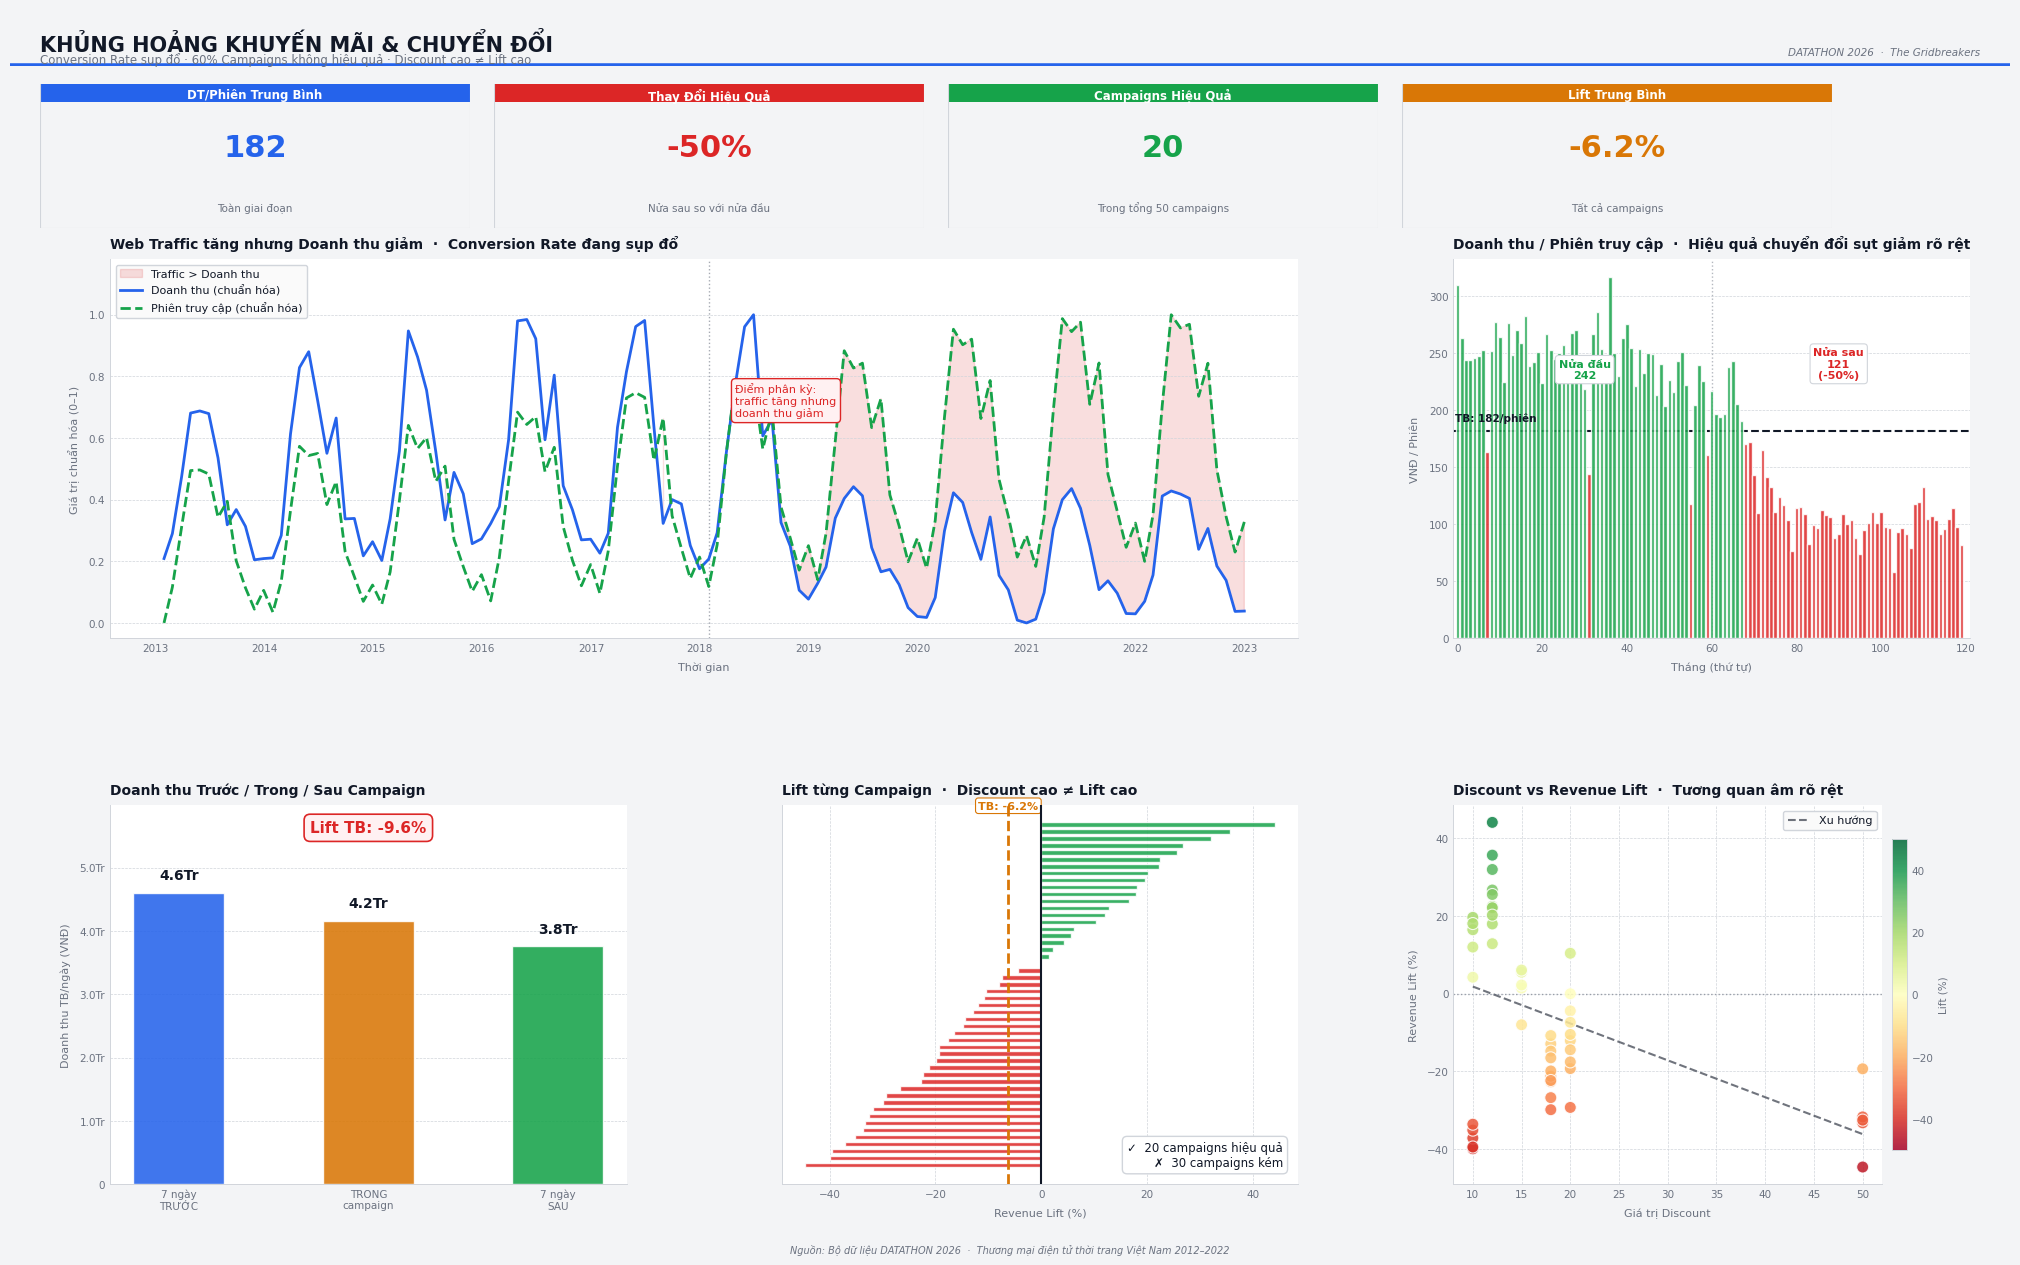

✓ Dashboard 4 (đồng bộ style) đã lưu!


In [9]:
sales_d  = dfs["sales.csv"].set_index("Date").sort_index()
traffic  = dfs["web_traffic.csv"].copy()
traffic["month"] = traffic["date"].dt.to_period("M").dt.to_timestamp("M")
traffic_m = traffic.groupby("month").agg(sessions=("sessions","sum")).reset_index()
sales_m   = sales_d["Revenue"].resample("ME").sum().reset_index()
sales_m.columns = ["month","revenue"]
sales_m["month"] = sales_m["month"].dt.to_period("M").dt.to_timestamp("M")
mg = sales_m.merge(traffic_m, on="month", how="inner")
mg = mg[mg["sessions"] > 0]
mg["rps"] = mg["revenue"] / mg["sessions"]

def norm(s): return (s - s.min()) / (s.max() - s.min())
mg["rn"] = norm(mg["revenue"]); mg["sn"] = norm(mg["sessions"])

promos = dfs["promotions.csv"].copy()
results = []
for _, pr in promos.iterrows():
    s, e = pr["start_date"], pr["end_date"]
    try:
        pre = sales_d.loc[s - pd.Timedelta(days=7): s - pd.Timedelta(days=1), "Revenue"].mean()
        dur = sales_d.loc[s:e, "Revenue"].mean()
        pst = sales_d.loc[e + pd.Timedelta(days=1): e + pd.Timedelta(days=7), "Revenue"].mean()
        if pd.notna(pre) and pre > 0:
            results.append({
                "discount": pr["discount_value"],
                "lift":     (dur - pre) / pre * 100,
                "pre": pre, "dur": dur,
                "post": pst if pd.notna(pst) else pre,
            })
    except:
        pass
res = pd.DataFrame(results)

# ── Màu Power BI — đồng bộ toàn bộ dashboards ───────────
WHITE   = "#FFFFFF"
BG_PAGE = "#F3F4F6"
BG_PLOT = "#FAFAFA"
BLUE    = "#2563EB"
GREEN   = "#16A34A"
ORANGE  = "#D97706"
RED     = "#DC2626"
PURPLE  = "#7C3AED"
TEAL    = "#0891B2"
GRAY1   = "#111827"
GRAY2   = "#6B7280"
GRAY3   = "#D1D5DB"

import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path

CHARTS_DIR = Path("./charts")
CHARTS_DIR.mkdir(exist_ok=True)

def M(x, _=None):
    if x is None: return ""
    x = float(x)
    if abs(x) >= 1e9: return f"{x/1e9:.1f}T"
    if abs(x) >= 1e6: return f"{x/1e6:.1f}Tr"
    if abs(x) >= 1e3: return f"{x/1e3:.0f}N"
    return f"{x:.0f}"

def style_ax(ax):
    ax.set_facecolor(WHITE)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color(GRAY3)
    ax.spines["bottom"].set_color(GRAY3)
    ax.tick_params(length=0)
    ax.xaxis.label.set_color(GRAY2)
    ax.yaxis.label.set_color(GRAY2)

plt.rcParams.update({
    "font.family":       "DejaVu Sans",
    "figure.facecolor":  BG_PAGE,
    "axes.facecolor":    BG_PLOT,
    "axes.edgecolor":    GRAY3,
    "axes.linewidth":    0.7,
    "axes.labelcolor":   GRAY2,
    "axes.titlesize":    10,
    "axes.titleweight":  "bold",
    "axes.titlepad":     8,
    "axes.labelsize":    8,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "xtick.labelsize":   7.5,
    "ytick.labelsize":   7.5,
    "xtick.color":       GRAY2,
    "ytick.color":       GRAY2,
    "xtick.major.size":  0,
    "ytick.major.size":  0,
    "grid.color":        GRAY3,
    "grid.linewidth":    0.5,
    "grid.linestyle":    "--",
    "legend.fontsize":   7.5,
    "legend.framealpha": 1.0,
    "legend.edgecolor":  GRAY3,
    "text.color":        GRAY1,
})

# ── KPI ──────────────────────────────────────────────────
avg_rps    = mg["rps"].mean()
rps_first  = mg["rps"].iloc[:len(mg)//2].mean()
rps_last   = mg["rps"].iloc[len(mg)//2:].mean()
rps_chg    = (rps_last - rps_first) / rps_first * 100
n_pos      = int((res["lift"] > 0).sum()) if not res.empty else 0
n_neg      = int(len(res) - n_pos) if not res.empty else 0
avg_lift   = res["lift"].mean() if not res.empty else 0

# ── Layout ────────────────────────────────────────────────
fig = plt.figure(figsize=(20, 12.5), facecolor=BG_PAGE)

# Header
header = fig.add_axes([0, 0.955, 1, 0.045])
header.set_facecolor(WHITE)
header.set_axis_off()
header.axhline(0, color=BLUE, linewidth=4)
fig.text(0.015, 0.973, "KHỦNG HOẢNG KHUYẾN MÃI & CHUYỂN ĐỔI", fontsize=15,
         fontweight="bold", color=GRAY1, va="center")
fig.text(0.015, 0.960, "Conversion Rate sụp đổ · 60% Campaigns không hiệu quả · Discount cao ≠ Lift cao",
         fontsize=8.5, color=GRAY2, va="center")
fig.text(0.985, 0.966, "DATATHON 2026  ·  The Gridbreakers",
         fontsize=7.5, color=GRAY2, ha="right", va="center", style="italic")

# ── KPI Cards ─────────────────────────────────────────────
kpi_data = [
    ("DT/Phiên Trung Bình",  M(avg_rps),         "Toàn giai đoạn",              BLUE,   "#EFF6FF"),
    ("Thay Đổi Hiệu Quả",   f"{rps_chg:+.0f}%", "Nửa sau so với nửa đầu",      RED,    "#FFF1F2"),
    ("Campaigns Hiệu Quả",  f"{n_pos}",          f"Trong tổng {len(res)} campaigns", GREEN, "#F0FDF4"),
    ("Lift Trung Bình",     f"{avg_lift:+.1f}%", "Tất cả campaigns",            ORANGE, "#FFFBEB"),
]

card_w, card_h = 0.215, 0.115
card_top  = 0.825
card_gaps = [0.015, 0.242, 0.469, 0.696]

for (label, value, sub, col, bg), x0 in zip(kpi_data, card_gaps):
    ax_c = fig.add_axes([x0, card_top, card_w, card_h])
    ax_c.set_facecolor(bg)
    ax_c.set_xlim(0, 1); ax_c.set_ylim(0, 1)
    ax_c.set_axis_off()
    ax_c.add_patch(mpatches.FancyBboxPatch(
        (0, 0.88), 1, 0.12, boxstyle="square,pad=0",
        facecolor=col, linewidth=0,
        transform=ax_c.transAxes, clip_on=False))
    for side, kw in [
        ("bottom", dict(y=0, xmin=0, xmax=1)),
        ("left",   dict(x=0, ymin=0, ymax=1)),
        ("right",  dict(x=1, ymin=0, ymax=1)),
    ]:
        if side == "bottom":
            ax_c.axhline(linewidth=0.8, color=GRAY3, **kw)
        else:
            ax_c.axvline(linewidth=0.8, color=GRAY3, **kw)
    ax_c.text(0.5, 0.97, label, ha="center", va="top",
              fontsize=8.5, color=WHITE, fontweight="600",
              transform=ax_c.transAxes)
    ax_c.text(0.5, 0.56, value, ha="center", va="center",
              fontsize=22, fontweight="bold", color=col,
              transform=ax_c.transAxes)
    ax_c.text(0.5, 0.10, sub, ha="center", va="bottom",
              fontsize=7.5, color=GRAY2,
              transform=ax_c.transAxes)

# ── Grid charts ───────────────────────────────────────────
gs = gridspec.GridSpec(2, 3, figure=fig,
    top=0.80, bottom=0.06,
    left=0.05, right=0.98,
    hspace=0.44, wspace=0.30)

# ── Chart 1: Traffic vs Doanh thu (chuẩn hóa) ────────────
ax1 = fig.add_subplot(gs[0, :2])
style_ax(ax1)
ax1.fill_between(mg["month"], mg["rn"], mg["sn"],
                 where=mg["sn"] > mg["rn"],
                 alpha=0.15, color=RED, label="Traffic > Doanh thu")
ax1.plot(mg["month"], mg["rn"], color=BLUE, lw=2,
         label="Doanh thu (chuẩn hóa)", zorder=3)
ax1.plot(mg["month"], mg["sn"], color=GREEN, lw=2, ls="--",
         label="Phiên truy cập (chuẩn hóa)", zorder=3)

# Điểm phân kỳ — dùng iloc thay quantile để tránh lỗi
mid_idx = len(mg) // 2
mid = mg["month"].iloc[mid_idx]
ax1.axvline(mid, color=GRAY2, lw=1, ls=":", alpha=0.6, zorder=2)

# Annotation đặt xa đường kẻ để không bị dính
ax1.text(mid + pd.DateOffset(months=3), 0.78,
         "Điểm phân kỳ:\ntraffic tăng nhưng\ndoanh thu giảm",
         fontsize=8, color=RED, va="top",
         bbox=dict(boxstyle="round,pad=0.35", fc="#FFF1F2", ec=RED, lw=1))

ax1.set_title("Web Traffic tăng nhưng Doanh thu giảm  ·  Conversion Rate đang sụp đổ",
              loc="left", color=GRAY1)
ax1.set_ylabel("Giá trị chuẩn hóa (0–1)", labelpad=6)
ax1.set_xlabel("Thời gian", labelpad=6)
ax1.set_ylim(-0.05, 1.18)   # thêm khoảng trên để label không đè lên đường
ax1.legend(fontsize=8, loc="upper left")
ax1.grid(axis="y", zorder=0)

# ── Chart 2: DT / Phiên truy cập ─────────────────────────
ax2 = fig.add_subplot(gs[0, 2])
style_ax(ax2)
cols_rps = [RED if v < mg["rps"].mean() else GREEN for v in mg["rps"]]
ax2.bar(range(len(mg)), mg["rps"], color=cols_rps, alpha=0.85,
        width=0.85, edgecolor=WHITE, zorder=3)

# Đường trung bình — vẽ trước, label đặt bên trái ngoài vùng bars
ax2.axhline(mg["rps"].mean(), color=GRAY1, lw=1.5, ls="--", zorder=2)
ax2.text(-0.5, mg["rps"].mean() * 1.04,
         f"TB: {M(mg['rps'].mean())}/phiên",
         fontsize=7.5, color=GRAY1, fontweight="600", va="bottom")

h = len(mg) // 2
r1, r2 = mg["rps"].iloc[:h].mean(), mg["rps"].iloc[h:].mean()
top = mg["rps"].max()

# Label nửa đầu/sau — đặt ở dưới đỉnh chart, cách đường kẻ
ax2.text(h * 0.5, top * 0.72,
         f"Nửa đầu\n{M(r1)}",
         ha="center", fontsize=8, color=GREEN, fontweight="600",
         bbox=dict(boxstyle="round,pad=0.3", fc=WHITE, ec=GRAY3, lw=0.8))
ax2.text(h * 1.5, top * 0.72,
         f"Nửa sau\n{M(r2)}\n({(r2-r1)/r1*100:+.0f}%)",
         ha="center", fontsize=8, color=RED, fontweight="600",
         bbox=dict(boxstyle="round,pad=0.3", fc=WHITE, ec=GRAY3, lw=0.8))

# Đường chia đôi
ax2.axvline(h, color=GRAY2, lw=1, ls=":", alpha=0.5, zorder=2)

ax2.set_title("Doanh thu / Phiên truy cập  ·  Hiệu quả chuyển đổi sụt giảm rõ rệt",
              loc="left", color=GRAY1)
ax2.set_ylabel("VNĐ / Phiên", labelpad=6)
ax2.set_xlabel("Tháng (thứ tự)", labelpad=6)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(M))
ax2.set_xlim(-1, len(mg) + 1)
ax2.grid(axis="y", zorder=0)

# ── Chart 3: Doanh thu Trước / Trong / Sau Campaign ──────
ax3 = fig.add_subplot(gs[1, 0])
style_ax(ax3)
if not res.empty:
    phases = ["7 ngày\nTRƯỚC", "TRONG\ncampaign", "7 ngày\nSAU"]
    means  = [res["pre"].mean(), res["dur"].mean(), res["post"].mean()]
    clrs   = [BLUE, ORANGE, GREEN]
    b3 = ax3.bar(phases, means, color=clrs, alpha=0.88,
                 edgecolor=WHITE, width=0.48, zorder=3)

    # Label số — đặt trên đỉnh bar với khoảng cách cố định
    y_offset = max(means) * 0.035
    for b, v in zip(b3, means):
        ax3.text(b.get_x() + b.get_width() / 2,
                 b.get_height() + y_offset,
                 M(v), ha="center", va="bottom",
                 fontsize=10, fontweight="bold", color=GRAY1)

    lp = (means[1] - means[0]) / means[0] * 100
    col_lift = RED if lp < 0 else GREEN
    bg_lift  = "#FFF1F2" if lp < 0 else "#F0FDF4"

    # Lift badge — đặt ở góc trên, tránh xa bars
    ax3.text(0.5, 0.96,
             f"Lift TB: {lp:+.1f}%",
             transform=ax3.transAxes, ha="center", va="top",
             fontsize=11, fontweight="bold", color=col_lift,
             bbox=dict(boxstyle="round,pad=0.4", fc=bg_lift, ec=col_lift, lw=1.2))

    # Đặt ylim cao hơn để label không đụng badge
    ax3.set_ylim(0, max(means) * 1.30)

ax3.set_title("Doanh thu Trước / Trong / Sau Campaign", loc="left", color=GRAY1)
ax3.set_ylabel("Doanh thu TB/ngày (VNĐ)", labelpad=6)
ax3.yaxis.set_major_formatter(mticker.FuncFormatter(M))
ax3.grid(axis="y", zorder=0)

# ── Chart 4: Phân phối Lift Campaign (horizontal bar) ────
ax4 = fig.add_subplot(gs[1, 1])
style_ax(ax4)
if not res.empty:
    lift_sorted = res["lift"].sort_values().values
    cols_l = [GREEN if l > 0 else RED for l in lift_sorted]
    ax4.barh(range(len(lift_sorted)), lift_sorted,
             color=cols_l, alpha=0.85, height=0.65,
             edgecolor=WHITE, zorder=3)

    # Đường 0 và đường trung bình — label đặt ở vị trí an toàn
    ax4.axvline(0, color=GRAY1, lw=1.5, zorder=4)
    mean_lift = res["lift"].mean()
    ax4.axvline(mean_lift, color=ORANGE, lw=2, ls="--", zorder=4)

    # Label TB đặt trên cùng chart, tránh xa bars
    ax4.text(mean_lift, len(lift_sorted) * 1.02,
             f"TB: {mean_lift:+.1f}%",
             ha="center", va="bottom",
             fontsize=8, color=ORANGE, fontweight="700",
             bbox=dict(boxstyle="round,pad=0.25", fc=WHITE, ec=ORANGE, lw=0.8))

    # Summary box — góc dưới phải
    ax4.text(0.97, 0.04,
             f"✓  {n_pos} campaigns hiệu quả\n✗  {n_neg} campaigns kém",
             transform=ax4.transAxes, ha="right", va="bottom",
             fontsize=8.5, color=GRAY1,
             bbox=dict(boxstyle="round,pad=0.4", fc=WHITE, ec=GRAY3, lw=1))

ax4.set_title("Lift từng Campaign  ·  Discount cao ≠ Lift cao",
              loc="left", color=GRAY1)
ax4.set_xlabel("Revenue Lift (%)", labelpad=6)
ax4.set_yticks([])
ax4.grid(axis="x", zorder=0)
ax4.grid(axis="y", visible=False)

# ── Chart 5: Discount vs Lift Scatter ────────────────────
ax5 = fig.add_subplot(gs[1, 2])
style_ax(ax5)
if not res.empty:
    sc = ax5.scatter(res["discount"], res["lift"],
                     c=res["lift"], cmap="RdYlGn",
                     vmin=-50, vmax=50,
                     s=75, alpha=0.85,
                     edgecolors=WHITE, linewidth=0.8, zorder=3)
    z  = np.polyfit(res["discount"], res["lift"], 1)
    xl = np.linspace(res["discount"].min(), res["discount"].max(), 100)
    ax5.plot(xl, np.poly1d(z)(xl), "--", color=GRAY1,
             lw=1.5, alpha=0.6, label="Xu hướng", zorder=2)

    # Đường 0 mờ
    ax5.axhline(0, color=GRAY2, lw=1, ls=":", alpha=0.6, zorder=2)

    # Colorbar
    cbar = plt.colorbar(sc, ax=ax5, shrink=0.82, aspect=22, pad=0.02)
    cbar.set_label("Lift (%)", fontsize=7.5)
    cbar.ax.tick_params(labelsize=7.5)

ax5.set_title("Discount vs Revenue Lift  ·  Tương quan âm rõ rệt",
              loc="left", color=GRAY1)
ax5.set_xlabel("Giá trị Discount", labelpad=6)
ax5.set_ylabel("Revenue Lift (%)", labelpad=6)
ax5.legend(fontsize=8)
ax5.grid(axis="both", zorder=0)

# Footer
fig.text(0.5, 0.005,
         "Nguồn: Bộ dữ liệu DATATHON 2026  ·  Thương mại điện tử thời trang Việt Nam 2012–2022",
         ha="center", fontsize=7, color=GRAY2, style="italic")

plt.savefig(CHARTS_DIR / "dashboard4_promotion_conversion.png",
            dpi=150, bbox_inches="tight", facecolor=BG_PAGE)
plt.show()
print("✓ Dashboard 4 (đồng bộ style) đã lưu!")

---
## DASHBOARD 5 — Dự báo Chiến lược & Khuyến nghị Hành động
**Cấp độ: Predictive + Prescriptive**


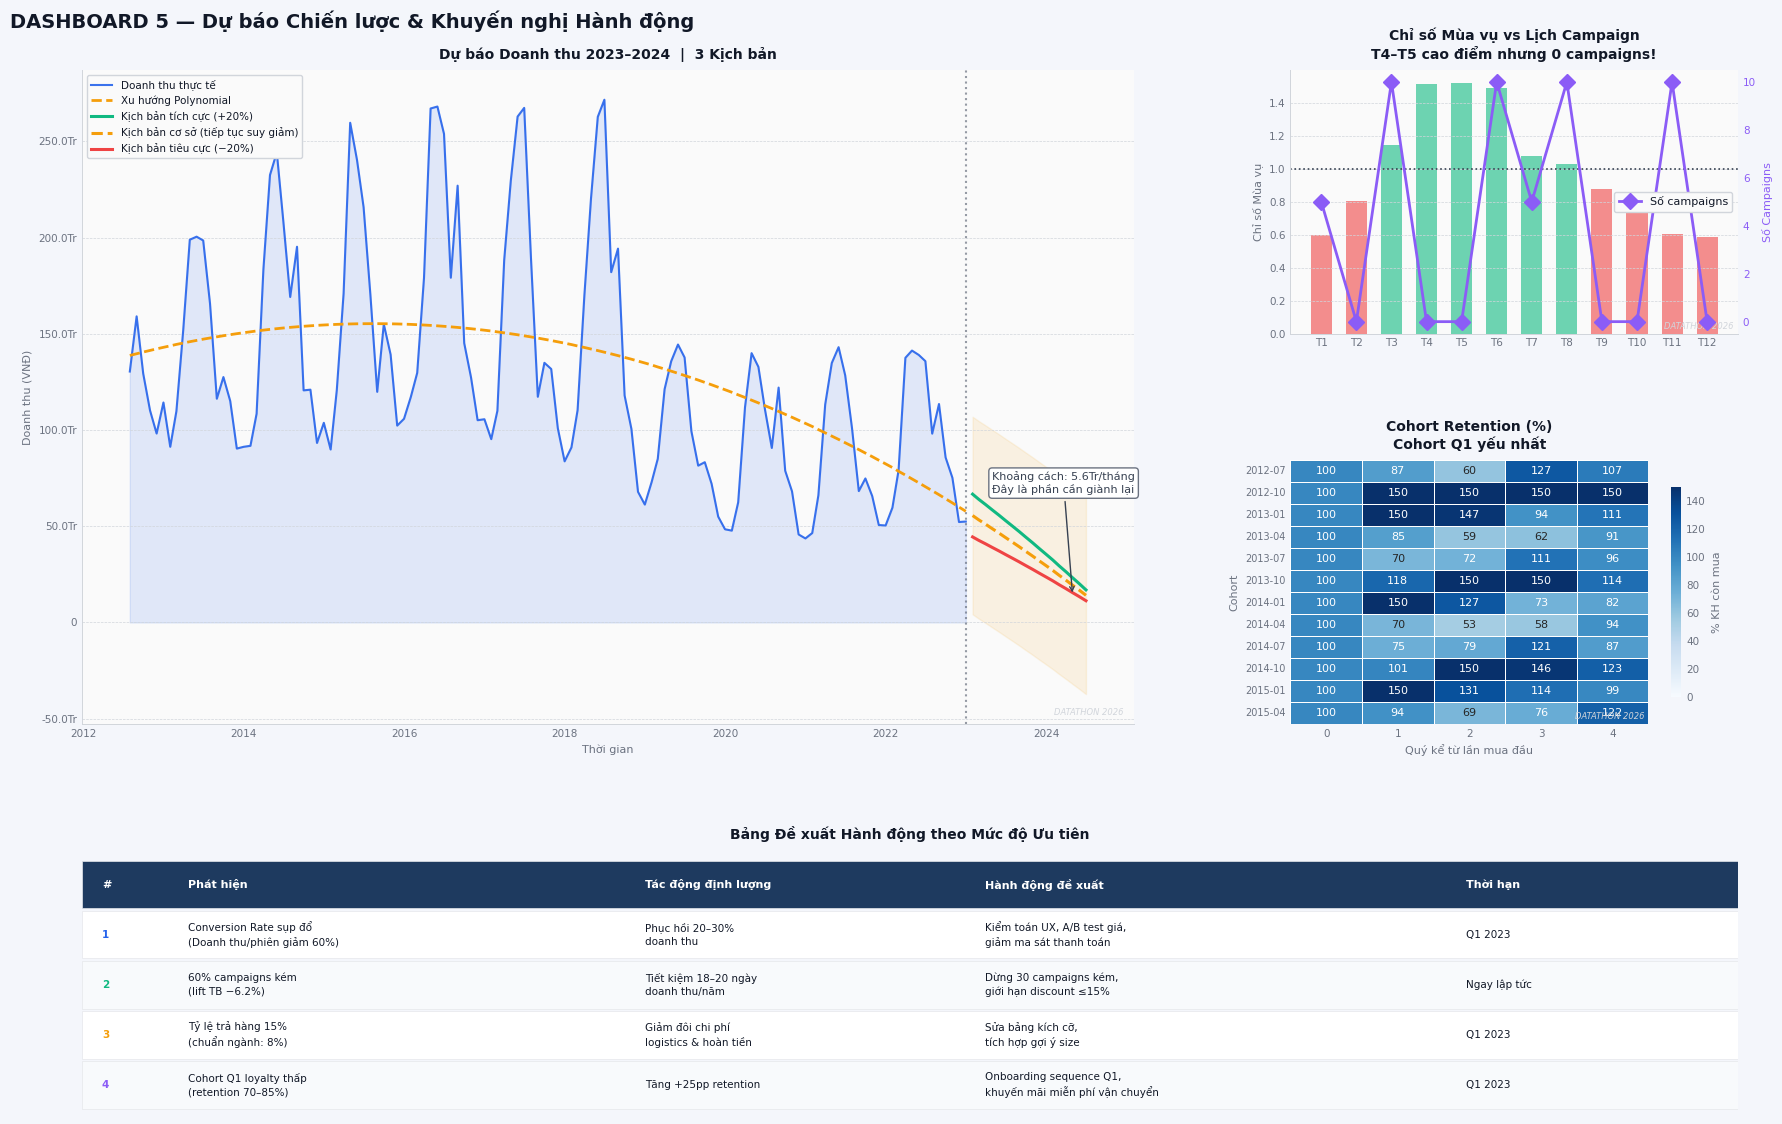

✓ Dashboard 5 đã lưu!


In [6]:
sales_fc = dfs["sales.csv"].copy()
sales_fc["Date"] = pd.to_datetime(sales_fc["Date"])
mfc = sales_fc.set_index("Date")["Revenue"].resample("ME").sum().reset_index()
mfc.columns = ["date","revenue"]
mfc["t"] = np.arange(len(mfc))

z = np.polyfit(mfc["t"], mfc["revenue"], 2)
p = np.poly1d(z)
t_fut = np.arange(len(mfc), len(mfc) + 18)
d_fut = pd.date_range(mfc["date"].iloc[-1] + pd.DateOffset(months=1), periods=18, freq="ME")
base = p(t_fut); opt = base * 1.20; pes = base * 0.80
std_fc = (mfc["revenue"] - p(mfc["t"])).std()

seas   = sales_fc.copy(); seas["mn"] = seas["Date"].dt.month
si     = seas.groupby("mn")["Revenue"].mean()
si_n   = si / si.mean()
camp_m = (dfs["promotions.csv"]["start_date"].dt.month
          .value_counts().reindex(range(1, 13), fill_value=0))

cust_fc = dfs["customers.csv"].copy()
cust_fc["signup_date"] = pd.to_datetime(cust_fc["signup_date"])
cust_fc["cohort"] = cust_fc["signup_date"].dt.to_period("Q").dt.to_timestamp()
ord_fc2 = dfs["orders.csv"].copy()
ord_fc2["order_date"] = pd.to_datetime(ord_fc2["order_date"])
ord_fc2 = ord_fc2[ord_fc2["order_status"].isin(["delivered","shipped"])]
dc = (ord_fc2
      .merge(cust_fc[["customer_id","cohort"]], on="customer_id", how="left")
      .dropna(subset=["cohort"]))
dc["period"]  = dc["order_date"].dt.to_period("Q").dt.to_timestamp()
dc["q_since"] = ((dc["period"] - dc["cohort"]) / pd.Timedelta(days=90)).round().astype(int)
dc = dc[dc["q_since"] >= 0]
coh_sz = dc[dc["q_since"] == 0].groupby("cohort")["customer_id"].nunique()
coh_d  = dc.groupby(["cohort","q_since"])["customer_id"].nunique().unstack(fill_value=0)
ret_m  = (coh_d.divide(coh_sz, axis=0) * 100)
ret_m  = ret_m[[c for c in [0,1,2,3,4] if c in ret_m.columns]].dropna(how="all").iloc[:12]

fig = plt.figure(figsize=(18, 12), facecolor=BG)
fig.suptitle("DASHBOARD 5 — Dự báo Chiến lược & Khuyến nghị Hành động",
             fontsize=14, fontweight="bold", x=0.01, ha="left", y=0.98)
gs = gridspec.GridSpec(3, 3, figure=fig,
                       hspace=0.48, wspace=0.35,
                       top=0.93, bottom=0.06, left=0.05, right=0.97)

# ── Dự báo 3 kịch bản ────────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[:2, :2])
ax1.fill_between(mfc["date"], mfc["revenue"], alpha=0.12, color=C1)
ax1.plot(mfc["date"], mfc["revenue"], color=C1, lw=1.5, alpha=0.9,
         label="Doanh thu thực tế")
ax1.plot(mfc["date"], p(mfc["t"]), color=C3, lw=2, ls="--",
         label="Xu hướng Polynomial")
ax1.axvline(mfc["date"].iloc[-1], color=GRAY, lw=1.5, ls=":", alpha=0.7)
ax1.plot(d_fut, opt,  color=C2, lw=2.2, label="Kịch bản tích cực (+20%)")
ax1.plot(d_fut, base, color=C3, lw=2.2, ls="--", label="Kịch bản cơ sở (tiếp tục suy giảm)")
ax1.plot(d_fut, pes,  color=C4, lw=2.2, label="Kịch bản tiêu cực (−20%)")
ax1.fill_between(d_fut, base - std_fc, base + std_fc, alpha=0.1, color=C3)
gap = opt[-1] - pes[-1]
ax1.annotate(
    f"Khoảng cách: {M(gap)}/tháng\nĐây là phần cần giành lại",
    xy=(d_fut[-3], (opt[-1] + pes[-1]) / 2),
    xytext=(d_fut[3], opt[3] * 1.15),
    fontsize=8, color="#374151",
    arrowprops=dict(arrowstyle="->", color="#374151"),
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=GRAY))
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(M))
ax1.set_title("Dự báo Doanh thu 2023–2024  |  3 Kịch bản")
ax1.set_xlabel("Thời gian"); ax1.set_ylabel("Doanh thu (VNĐ)")
ax1.legend(fontsize=7.5, loc="upper left"); ax1.grid(axis="y"); wm(ax1)

# ── Chỉ số mùa vụ vs Lịch Campaign ──────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 2])
ax2b = ax2.twinx()
xm = np.arange(1, 13)
ml = ["T1","T2","T3","T4","T5","T6","T7","T8","T9","T10","T11","T12"]
cols_s = [C2 if v >= 1.0 else C4 for v in si_n.values]
ax2.bar(xm, si_n.values, color=cols_s, alpha=0.6, width=0.6)
ax2.axhline(1.0, color="#374151", lw=1.2, ls=":")
ax2b.plot(xm, camp_m.values, "D-", color=C5, lw=2, markersize=8, label="Số campaigns")
ax2.set_xticks(xm); ax2.set_xticklabels(ml, fontsize=7.5)
ax2.set_title("Chỉ số Mùa vụ vs Lịch Campaign\nT4–T5 cao điểm nhưng 0 campaigns!")
ax2.set_ylabel("Chỉ số Mùa vụ")
ax2b.set_ylabel("Số Campaigns", color=C5)
ax2b.tick_params(axis="y", labelcolor=C5)
ax2b.legend(fontsize=8)
ax2.grid(axis="y"); wm(ax2)

# ── Cohort Retention ─────────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 2])
if not ret_m.empty and len(ret_m) >= 3:
    sns.heatmap(ret_m.clip(upper=150), ax=ax3, annot=True, fmt=".0f",
                cmap="Blues", linewidths=0.5, linecolor="white",
                vmin=0, vmax=150, annot_kws={"size": 8},
                cbar_kws={"label": "% KH còn mua", "shrink": 0.8})
    ax3.set_title("Cohort Retention (%)\nCohort Q1 yếu nhất")
    ax3.set_xlabel("Quý kể từ lần mua đầu"); ax3.set_ylabel("Cohort")
    ax3.set_yticklabels([str(t)[:7] for t in ret_m.index], rotation=0, fontsize=7)
wm(ax3)

# ── Bảng Khuyến nghị Hành động ───────────────────────────────────────────────
ax4 = fig.add_subplot(gs[2, :])
ax4.set_facecolor(CARD); ax4.set_xlim(0, 1); ax4.set_ylim(0, 1); ax4.axis("off")

rows = [
    ["#", "Phát hiện",               "Tác động định lượng",           "Hành động đề xuất",               "Thời hạn"],
    ["1", "Conversion Rate sụp đổ\n(Doanh thu/phiên giảm 60%)", "Phục hồi 20–30%\ndoanh thu",    "Kiểm toán UX, A/B test giá,\ngiảm ma sát thanh toán",       "Q1 2023"],
    ["2", "60% campaigns kém\n(lift TB −6.2%)",                 "Tiết kiệm 18–20 ngày\ndoanh thu/năm","Dừng 30 campaigns kém,\ngiới hạn discount ≤15%",       "Ngay lập tức"],
    ["3", "Tỷ lệ trả hàng 15%\n(chuẩn ngành: 8%)",            "Giảm đôi chi phí\nlogistics & hoàn tiền","Sửa bảng kích cỡ,\ntích hợp gợi ý size",        "Q1 2023"],
    ["4", "Cohort Q1 loyalty thấp\n(retention 70–85%)",         "Tăng +25pp retention",          "Onboarding sequence Q1,\nkhuyến mãi miễn phí vận chuyển",   "Q1 2023"],
]

cw = [0.04, 0.28, 0.20, 0.30, 0.12]
cx = [0.01]
for w in cw[:-1]: cx.append(cx[-1] + w)
rc = [C1, C2, C3, C5]

for ri, row in enumerate(rows):
    y  = 0.92 - ri * 0.19
    bg = "#1E3A5F" if ri == 0 else ("#F8FAFC" if ri % 2 == 0 else "#FFFFFF")
    ax4.add_patch(plt.Rectangle(
        (0, y - 0.14), 1, 0.18,
        facecolor=bg, edgecolor="#E5E7EB", linewidth=0.5,
        transform=ax4.transAxes))
    for ci, (cell, x_) in enumerate(zip(row, cx)):
        fc = "white" if ri == 0 else (rc[ri - 1] if ci == 0 else "#111827")
        fw = "bold" if (ri == 0 or ci == 0) else "normal"
        ax4.text(x_ + cw[ci] * 0.05, y - 0.05, cell,
                 fontsize=8 if ri == 0 else 7.5,
                 color=fc, fontweight=fw,
                 va="center", ha="left", linespacing=1.4,
                 transform=ax4.transAxes)
ax4.set_title("Bảng Đề xuất Hành động theo Mức độ Ưu tiên",
              fontsize=10, fontweight="bold", pad=8)

plt.savefig(CHARTS_DIR / "dashboard5_strategic_summary.png",
            dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()
print("✓ Dashboard 5 đã lưu!")

---
## Tổng kết

| Dashboard | Nội dung | Cấp độ |
|---|---|---|
| 1 — Tổng quan Doanh thu | KPI cards, xu hướng, YoY, heatmap mùa vụ | Descriptive + Predictive |
| 2 — Phân tích Sản phẩm | Doanh thu danh mục, biên lợi nhuận, tỷ lệ trả hàng | Descriptive + Diagnostic |
| 3 — Phân tích Khách hàng | Vùng, nhóm tuổi, kênh tiếp thị | Diagnostic + Prescriptive |
| 4 — Khuyến mãi & Chuyển đổi | Traffic vs doanh thu, lift campaign, discount | Diagnostic + Prescriptive |
| 5 — Chiến lược & Dự báo | 3 kịch bản, cohort retention, bảng hành động | Predictive + Prescriptive |

**5 file PNG đã lưu vào thư mục `charts/` — dùng cho báo cáo NeurIPS.**
